In [114]:
import pandas as pd
from pathlib import Path
import numpy as np
import seaborn as sns

# from posydon.popsyn.binarypopulation import BinaryPopulation
# from posydon.binary_evol.binarystar import BinaryStar
# from posydon.binary_evol.singlestar import SingleStar
from posydon.popsyn.synthetic_population import Population
# from posydon.popsyn.synthetic_population import PopulationRunner
# import astropy.units as u
# 
# import os
# import shutil
# from posydon.config import PATH_TO_POSYDON

from POSYDONHRDiagramModule import HR_Diagram

import matplotlib.pyplot as plt
import matplotlib as mpl

import random as rand 

from collections import Counter

DataPath = Path().resolve().parent / 'Data'


In [115]:
cols = ['time', 'step_names', 'state', 'event', 'S1_state', 'S2_state', 'S1_mass', 'S2_mass', 'orbital_period']
finCols = [
    'orbital_period_f',
    'eccentricity_f',
    'state_f',

    'S1_state_f',
    'S2_state_f',
    
    'S2_mass_f',
    'S2_log_R_f',
    'S2_log_L_f',


    'S1_mass_f',
    'S1_log_R_f',
    'S1_log_L_f'

 ]

initCols = [
    'orbital_period_i',
    'eccentricity_i',
    'state_i',

    'S2_state_i',
    'S2_mass_i',
    'S2_log_R_i',

    'S1_state_i',
    'S1_mass_i',
    'S1_log_R_i'
 ]

In [116]:
mpl.rcParams.update({
    "pgf.texsystem": "pdflatex",  
    "font.family": "serif",       
    "text.usetex": True,          
    "pgf.rcfonts": False,         
})

In [117]:
def basicColHist(df, var: str, title: str | None = None, xLabel: str | None = None, saveFig: bool = False, savePath: Path = Path()) -> None:
    fig, ax = plt.subplots(figsize=(8,5))
    
    sns.histplot(df[var], bins=50, ax=ax)
    
    if title is None:
        title = f'{var} of BH-Sol systems at S1 SN'
    if xLabel is None:
        xLabel = var

    ax.set_title(title)
    ax.set_xlabel(xLabel)
    ax.set_ylabel('Count')

    if saveFig:
        clean_name = title.replace(' ', '_').replace('/', '-') + '.pgf'
        plt.savefig(savePath / clean_name, bbox_inches='tight')

    plt.show()

def genVarHist(var: list, title: str | None = None, xLabel: str | None = None, saveFig: bool = False, savePath: Path = Path()) -> None:
    fig, ax = plt.subplots(figsize=(8,5))
    
    sns.histplot(var, bins=50, ax=ax)
    
    if title is None:
        title = 'default'
    if xLabel is None:
        xLabel = 'default'

    ax.set_title(title)
    ax.set_xlabel(xLabel)
    ax.set_ylabel('Count')

    if saveFig:
        clean_name = title.replace(' ', '_').replace('/', '-') + '.pgf'
        plt.savefig(savePath / clean_name, bbox_inches='tight')

    plt.show()

In [118]:
def xVsY(
    xvar: str|list, yvar: str|list,
    df: pd.DataFrame | None = None,
    useDF: bool = True, 
    title: str | None = None,
    xLabel: str | None = None,
    yLabel: str | None = None,
    saveFig: bool = False,
    savePath: Path = Path(),
    fit: bool = False,
    ci: int = 95
) -> None:
    fig, ax = plt.subplots(figsize=(8, 5))

    if useDF:
        x = df[xvar] if isinstance(xvar, str) else xvar
        y = df[yvar] if isinstance(yvar, str) else yvar
    else:
        x, y = xvar, yvar  
        
    if fit:
        sns.regplot(x=x, y=y, ci=ci, ax=ax,
                    line_kws={"color": "red", "linestyle": "--", "linewidth": 2},
                    scatter_kws={"alpha": 0.6})
    else:
        sns.scatterplot(x=x, y=y, alpha=0.6, ax=ax)

    if title is None:
        if isinstance(xvar, str) and isinstance(yvar, str):
            title = f'{xvar} vs {yvar} of BH-Sol systems at S1 SN'
        else:
            title = 'Variable Comparison'

    if xLabel is None:
        xLabel = xvar if isinstance(xvar, str) else 'X-Axis'
        
    if yLabel is None:
        yLabel = yvar if isinstance(yvar, str) else 'Y-Axis'

    ax.set_title(title)
    ax.set_xlabel(xLabel)
    ax.set_ylabel(yLabel)

    if saveFig:
        clean_name = title.replace(' ', '_').replace('/', '-') + '.pgf'
        plt.savefig(savePath / clean_name, bbox_inches='tight')

    plt.show()

In [119]:
# ### sunlike
# pop = Population(str(DataPath / 'SunLikeStar_Filt' / 'BH_Sol_Filtered_1e+00_Zsun_population.h5'))
# bhSolRows = pd.read_csv(DataPath /'SunLikeStar_Filt' / 'BH_Sol_Filtered_1e+00_Zsun_population.csv')
# bhSolRows_Aftr = pd.read_csv(DataPath /'SunLikeStar_Filt' / 'BH_Sol_Filtered_1e+00_Zsun_populationAftRow.csv')
# bhSolRows_Prev = pd.read_csv(DataPath /'SunLikeStar_Filt' / 'BH_Sol_Filtered_1e+00_Zsun_populationprevRow.csv')

# bhSolRows = bhSolRows.drop(17, axis='index')
# bhSolRows_Aftr = bhSolRows_Aftr.drop(17, axis='index')
# bhSolRows_Prev = bhSolRows_Prev.drop(17, axis='index')


# pOneline = pop.oneline.select()
# pHistory = pop.history.select()

# pOneline = pOneline.drop(17, axis='index')
# pHistory = pHistory.drop(17, axis='index')

# pop.ini_params

In [120]:
### 10MilPop
pop = Population(str(DataPath / '10MillFilt' / 'BH_Sol_Filtered_1e+00_Zsun_population.h5'))
bhSolRows = pd.read_csv(DataPath /'10MillFilt' / 'BH_Sol_Filtered_1e+00_Zsun_population.csv')
bhSolRows_Aftr = pd.read_csv(DataPath /'10MillFilt' / 'BH_Sol_Filtered_1e+00_Zsun_populationAftRow.csv')
bhSolRows_Prev = pd.read_csv(DataPath /'10MillFilt' / 'BH_Sol_Filtered_1e+00_Zsun_populationprevRow.csv')

bhSolRows['deltaM1SN'] = (bhSolRows_Prev['S1_mass'] - bhSolRows['S1_mass'])
dropIs = bhSolRows['deltaM1SN'].nsmallest(2).index.to_list() # <- these are two systems where its RLO onto a NS which then collapses into a BH, but they both error out and arent really what we're looking for? so easier to drop


bhSolRows = bhSolRows.drop(dropIs, axis='index')
bhSolRows_Aftr = bhSolRows_Aftr.drop(dropIs, axis='index')
bhSolRows_Prev = bhSolRows_Prev.drop(dropIs, axis='index')


pOneline = pop.oneline.select()
pHistory = pop.history.select()

pOneline = pOneline.drop(dropIs, axis='index')
pHistory = pHistory.drop(dropIs, axis='index')

pop.ini_params



Missing ini parameter: posydon_version


{'metallicity': 1.0,
 'number_of_binaries': 10000000,
 'binary_fraction_scheme': 'const',
 'binary_fraction_const': 1.0,
 'star_formation': 'constant',
 'max_simulation_time': 13800000000.0,
 'primary_mass_scheme': 'Kroupa2001',
 'primary_mass_min': 4,
 'primary_mass_max': 150.0,
 'secondary_mass_scheme': 'Moe+17-PsandQs',
 'secondary_mass_min': 0.1,
 'secondary_mass_max': 150.0,
 'orbital_scheme': 'period',
 'orbital_period_scheme': 'Moe+17-PsandQs',
 'orbital_period_min': 0.75,
 'orbital_period_max': 10000,
 'orbital_separation_scheme': 'log_uniform',
 'orbital_separation_min': 5.0,
 'orbital_separation_max': 100000.0,
 'eccentricity_scheme': 'zero'}

In [121]:
####1d-02Zsun
pop_02Z = Population(str(DataPath / '1e-02Zsun' / 'BH_Sol_Filtered_1e-02_Zsun_population.h5'))
bhSolRows_02Z = pd.read_csv(DataPath /'1e-02Zsun' / 'BH_Sol_Filtered_1e-02_Zsun_population.csv')

bhSolRows_Aftr_02Z = pd.read_csv(DataPath /'1e-02Zsun' / 'BH_Sol_Filtered_1e-02_Zsun_populationAftRow.csv')
bhSolRows_Prev_02Z = pd.read_csv(DataPath /'1e-02Zsun' / 'BH_Sol_Filtered_1e-02_Zsun_populationprevRow.csv')


pOneline_02Z = pop.oneline.select()
pHistory_02Z = pop.history.select()

fc = pop_02Z.formation_channels
mask = fc['channel'] == 'ZAMS_oCE1_CC1_oRLO2_CC2_maxtime_END'
binary_indices_02Z = fc[mask].index.tolist()

pOneline_02Z = pop_02Z.oneline[binary_indices_02Z]
pHistory_02Z = pop_02Z.history[binary_indices_02Z]

bhSolRows_02Z = bhSolRows_02Z.loc[binary_indices_02Z]

pop_02Z.ini_params


{'metallicity': 0.01,
 'number_of_binaries': 1000000,
 'binary_fraction_scheme': 'const',
 'binary_fraction_const': 1.0,
 'star_formation': 'constant',
 'max_simulation_time': 13800000000.0,
 'primary_mass_scheme': 'Kroupa2001',
 'primary_mass_min': 12,
 'primary_mass_max': 100,
 'secondary_mass_scheme': 'Moe+17-PsandQs',
 'secondary_mass_min': 0.1,
 'secondary_mass_max': 10,
 'orbital_scheme': 'period',
 'orbital_period_scheme': 'Moe+17-PsandQs',
 'orbital_period_min': 5,
 'orbital_period_max': 8000,
 'orbital_separation_scheme': 'log_uniform',
 'orbital_separation_min': 5.0,
 'orbital_separation_max': 100000.0,
 'eccentricity_scheme': 'zero',
 'posydon_version': '0+unknown'}

In [122]:
pOneline_02Z

,state_i,event_i,time_i,orbital_period_i,eccentricity_i,lg_mtransfer_rate_i,step_names_i,step_times_i,S1_state_i,S1_mass_i,...,interp_class_CO_HMS_RLO,interp_class_CO_HeMS,interp_class_CO_HeMS_RLO,mt_history_HMS_HMS,mt_history_CO_HMS_RLO,mt_history_CO_HeMS,mt_history_CO_HeMS_RLO,FAILED,WARNING,metallicity
binary_index,,,,,,,,,,,,,,,,,,,,,
0,detached,ZAMS,4.035779e+09,2601.184779,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,18.182762,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,0.01
2,detached,ZAMS,3.076035e+09,3136.277507,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,17.256266,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,0.01
3,detached,ZAMS,3.911211e+09,3002.832222,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,17.103747,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,0.01
4,detached,ZAMS,7.092487e+09,2864.788796,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,15.841658,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,0.01
5,detached,ZAMS,8.921784e+09,3010.813232,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,17.526981,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,0.01
6,detached,ZAMS,3.719153e+08,2922.317516,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,15.028368,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,0.01
7,detached,ZAMS,8.156287e+09,3012.777478,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,16.202626,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,0.01
8,detached,ZAMS,7.275431e+08,2972.226028,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,15.916362,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,0.01
11,detached,ZAMS,3.326343e+09,3056.267366,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,15.492378,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,0.01


In [123]:
pOneline_02Z

,state_i,event_i,time_i,orbital_period_i,eccentricity_i,lg_mtransfer_rate_i,step_names_i,step_times_i,S1_state_i,S1_mass_i,...,interp_class_CO_HMS_RLO,interp_class_CO_HeMS,interp_class_CO_HeMS_RLO,mt_history_HMS_HMS,mt_history_CO_HMS_RLO,mt_history_CO_HeMS,mt_history_CO_HeMS_RLO,FAILED,WARNING,metallicity
binary_index,,,,,,,,,,,,,,,,,,,,,
0,detached,ZAMS,4.035779e+09,2601.184779,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,18.182762,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,0.01
2,detached,ZAMS,3.076035e+09,3136.277507,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,17.256266,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,0.01
3,detached,ZAMS,3.911211e+09,3002.832222,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,17.103747,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,0.01
4,detached,ZAMS,7.092487e+09,2864.788796,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,15.841658,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,0.01
5,detached,ZAMS,8.921784e+09,3010.813232,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,17.526981,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,0.01
6,detached,ZAMS,3.719153e+08,2922.317516,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,15.028368,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,0.01
7,detached,ZAMS,8.156287e+09,3012.777478,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,16.202626,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,0.01
8,detached,ZAMS,7.275431e+08,2972.226028,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,15.916362,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,0.01
11,detached,ZAMS,3.326343e+09,3056.267366,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,15.492378,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,0.01


In [124]:
pOneline

,state_i,event_i,time_i,separation_i,orbital_period_i,eccentricity_i,rl_relative_overflow_1_i,rl_relative_overflow_2_i,lg_mtransfer_rate_i,step_names_i,...,interp_class_CO_HMS_RLO,interp_class_CO_HeMS,interp_class_CO_HeMS_RLO,mt_history_HMS_HMS,mt_history_CO_HMS_RLO,mt_history_CO_HeMS,mt_history_CO_HeMS_RLO,FAILED,WARNING,metallicity
binary_index,,,,,,,,,,,,,,,,,,,,,
0,detached,ZAMS,8.986912e+09,2919.300237,4138.854009,0.0,NaN,NaN,NaN,initial_cond,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0
1,detached,ZAMS,5.307688e+09,2931.796105,4214.058792,0.0,NaN,NaN,NaN,initial_cond,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0
2,detached,ZAMS,8.486257e+09,2845.924808,4123.090826,0.0,NaN,NaN,NaN,initial_cond,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0
3,detached,ZAMS,6.315842e+07,2981.541957,4342.833283,0.0,NaN,NaN,NaN,initial_cond,...,NaN,NaN,NaN,Unstable RLOF during postMS,NaN,NaN,NaN,0,1,1.0
4,detached,ZAMS,4.657077e+09,2877.764076,4127.376889,0.0,NaN,NaN,NaN,initial_cond,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,detached,ZAMS,7.942877e+09,2845.694725,4159.486756,0.0,NaN,NaN,NaN,initial_cond,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0
103,detached,ZAMS,5.785051e+09,2896.943115,3966.766286,0.0,NaN,NaN,NaN,initial_cond,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0
104,detached,ZAMS,6.964517e+09,2879.043280,4059.758619,0.0,NaN,NaN,NaN,initial_cond,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0


In [125]:
bhSolRows[cols]

,time,step_names,state,event,S1_state,S2_state,S1_mass,S2_mass,orbital_period
0,8.999790e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,4.497844,2.188440,2.759667
1,5.320878e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,2.889235,2.576325,5.665033
2,8.501130e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,4.083570,2.210207,19.815499
3,7.629853e+07,step_SN,detached,NaN,BH,H-rich_Core_H_burning,4.164916,1.418179,0.876181
4,4.671309e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,3.631062,2.705397,7.931873
...,...,...,...,...,...,...,...,...,...
102,7.958286e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,3.879835,2.241023,109.989868
103,5.797456e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,4.492126,2.935552,13.746755
104,6.978108e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,3.932124,2.849538,6.730866
105,3.801350e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,3.842938,2.013448,36.878780


In [126]:
bhSolRows_Prev[cols]

,time,step_names,state,event,S1_state,S2_state,S1_mass,S2_mass,orbital_period
0,8.999790e+09,step_detached,detached,CC1,stripped_He_Core_He_depleted,H-rich_Core_H_burning,8.040238,2.188440,1.599223
1,5.320878e+09,step_detached,detached,CC1,stripped_He_Core_He_depleted,H-rich_Core_H_burning,6.934508,2.576325,2.071923
2,8.501130e+09,step_detached,detached,CC1,stripped_He_Core_He_depleted,H-rich_Core_H_burning,7.685418,2.210207,30.046101
3,7.629853e+07,step_detached,detached,CC1,stripped_He_Core_C_depleted,H-rich_Core_H_burning,7.797229,1.418179,0.951980
4,4.671309e+09,step_detached,detached,CC1,stripped_He_Core_He_depleted,H-rich_Core_H_burning,7.260721,2.705397,6.763024
...,...,...,...,...,...,...,...,...,...
102,7.958286e+09,step_detached,detached,CC1,stripped_He_Core_He_depleted,H-rich_Core_H_burning,7.522512,2.241023,48.794430
103,5.797456e+09,step_detached,detached,CC1,stripped_He_Core_He_depleted,H-rich_Core_H_burning,8.435668,2.935552,4.817070
104,6.978108e+09,step_detached,detached,CC1,stripped_He_Core_He_depleted,H-rich_Core_H_burning,7.579561,2.849538,6.108189
105,3.801350e+09,step_detached,detached,CC1,stripped_He_Core_C_depleted,H-rich_Core_H_burning,7.483127,2.013448,4.719992


In [127]:
bhSolRows_Aftr

,binary_index,state,event,time,separation,orbital_period,eccentricity,rl_relative_overflow_1,rl_relative_overflow_2,lg_mtransfer_rate,...,S2_conv_env_turnover_time_l_b,S2_conv_env_turnover_time_l_t,S2_envelope_binding_energy,S2_mass_conv_reg_fortides,S2_thickness_conv_reg_fortides,S2_radius_conv_reg_fortides,S2_lambda_CE_1cent,S2_lambda_CE_10cent,S2_lambda_CE_30cent,S2_lambda_CE_pure_He_star_10cent
0,98167,RLO2,oRLO2,9.700018e+09,11.072281,1.651567,0.0,-1.0,-0.05,NaN,...,2.419792e-03,-1.000000e+99,-7.605935e+48,2.072318e-08,0.016396,3.310177,0.705574,0.705574,0.577858,0.705574
1,164933,RLO2,oRLO2,5.802279e+09,14.426048,2.715509,0.0,-1.0,-0.05,NaN,...,3.255769e-01,-1.000000e+99,-9.399791e+48,5.105589e-08,0.030850,4.979006,0.477672,0.476081,0.471506,0.516066
2,421025,RLO2,oRLO2,9.254013e+09,38.594193,11.074943,0.0,-1.0,-0.05,NaN,...,2.915205e-01,8.973267e+06,-1.329238e+48,1.725270e+00,10.224585,6.881251,0.975518,1.044759,1.431375,0.391519
3,432008,RLO2,oRLO2,3.636572e+08,5.141004,0.571583,0.0,-1.0,-0.05,NaN,...,7.557347e-05,1.535035e+03,-5.600139e+48,1.364665e-08,0.014287,1.413024,0.956737,0.956737,0.956737,0.956737
4,469540,RLO2,oRLO2,5.096827e+09,28.987903,7.187819,0.0,-1.0,-0.05,NaN,...,1.617791e-03,-9.109267e+96,-6.681137e+48,1.039393e-05,0.332342,9.565899,0.375418,0.385855,0.401217,0.364681
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,9869876,RLO2,oRLO2,8.676509e+09,19.995739,4.189868,0.0,-1.0,-0.05,NaN,...,-3.785224e+88,-9.826494e+98,-6.522716e+48,4.109121e-07,0.096240,6.255634,0.411393,0.416214,0.420793,0.422442
103,9893810,RLO2,oRLO2,6.139847e+09,26.811159,5.903945,0.0,-1.0,-0.05,NaN,...,-3.168754e+91,-1.000000e+99,-8.494567e+48,3.380672e-07,0.083234,8.559268,0.390569,0.397709,0.406464,0.394797
104,9898281,RLO2,oRLO2,7.351047e+09,25.374958,5.694745,0.0,-1.0,-0.05,NaN,...,-3.168754e+91,-1.000000e+99,-8.157106e+48,3.369270e-07,0.081352,8.301011,0.391490,0.398448,0.406859,0.396030
105,9912445,RLO2,oRLO2,4.780827e+09,24.528425,5.818847,0.0,-1.0,-0.05,NaN,...,4.185275e-01,1.156130e+07,-1.652807e+48,1.341449e+00,5.530165,4.795622,1.048449,1.113475,1.378872,0.574567


In [128]:
####1d-01Zsun
# pop = Population(str(DataPath / '1e-01Zsun' / 'BH_Sol_Filtered_1e-01_Zsun_population.h5'))
# bhSolRows = pd.read_csv(DataPath /'1e-01Zsun' / 'BH_Sol_Filtered_1e-01_Zsun_population.csv')

In [129]:
pop.calculate_formation_channels()

Formation channels already exist in the parsed population file!
Channels will be overwriten


In [130]:
Counter(pop.formation_channels['channel'])

Counter({'ZAMS_oCE1_CC1_oRLO2_CC2_maxtime_END': 82,
         'ZAMS_oCE1_CC1_END': 10,
         'ZAMS_oCE1_CC1_oRLO2_maxtime_END': 9,
         'ZAMS_oCE1_CC1_oRLO2_CC2_FAILED': 3,
         'ZAMS_oRLO1_CC1_oRLO2_CC2_FAILED': 2,
         'ZAMS_oCE1_CC1_oRLO2_oRLO2_END': 1})

In [131]:
bhSolRows

,binary_index,state,event,time,separation,orbital_period,eccentricity,rl_relative_overflow_1,rl_relative_overflow_2,lg_mtransfer_rate,...,S2_conv_env_turnover_time_l_t,S2_envelope_binding_energy,S2_mass_conv_reg_fortides,S2_thickness_conv_reg_fortides,S2_radius_conv_reg_fortides,S2_lambda_CE_1cent,S2_lambda_CE_10cent,S2_lambda_CE_30cent,S2_lambda_CE_pure_He_star_10cent,deltaM1SN
0,98167,detached,NaN,8.999790e+09,15.592295,2.759667,0.351460,NaN,NaN,NaN,...,0.000000,-1.060802e+49,1.376460e-09,0.003673,1.596058,1.059250,1.059250,1.059250,1.059250,3.542394
1,164933,detached,NaN,5.320878e+09,23.548169,5.665033,0.393018,NaN,NaN,NaN,...,0.000000,-1.306797e+49,1.275745e-09,0.003705,1.749940,1.087898,1.087898,1.087898,1.087898,4.045273
2,421025,detached,NaN,8.501130e+09,56.874522,19.815499,0.541184,NaN,NaN,NaN,...,0.000000,-1.074448e+49,1.368844e-09,0.003717,1.604894,1.060897,1.060897,1.060897,1.060897,3.601848
3,432008,detached,NaN,7.629853e+07,6.833317,0.876181,0.250778,NaN,NaN,NaN,...,2289.310733,-5.554021e+48,4.375370e-08,0.018593,1.386301,0.976688,0.976688,0.976688,0.976688,3.632313
4,469540,detached,NaN,4.671309e+09,30.960643,7.931873,0.062861,NaN,NaN,NaN,...,0.000000,-1.389527e+49,1.257137e-09,0.003917,1.801025,1.096518,1.096518,1.096518,1.096518,3.629659
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,9869876,detached,NaN,7.958286e+09,176.651172,109.989868,0.886831,NaN,NaN,NaN,...,0.000000,-1.093747e+49,1.358731e-09,0.003729,1.617445,1.063203,1.063203,1.063203,1.063203,3.642677
103,9893810,detached,NaN,5.797456e+09,47.100819,13.746755,0.431066,NaN,NaN,NaN,...,0.000000,-1.542464e+49,1.212454e-09,0.003906,1.882450,1.113239,1.113239,1.113239,1.113239,3.943543
104,9898281,detached,NaN,6.978108e+09,28.385943,6.730866,0.105824,NaN,NaN,NaN,...,0.000000,-1.483731e+49,1.233944e-09,0.003928,1.855052,1.106384,1.106384,1.106384,1.106384,3.647436
105,9912445,detached,NaN,3.801350e+09,84.011404,36.878780,0.713982,NaN,NaN,NaN,...,0.000000,-9.481873e+48,1.490166e-09,0.003777,1.534551,1.042847,1.042847,1.042847,1.042847,3.640189


In [132]:
pOneline[pOneline['S2_mass_i'] > 3]

,state_i,event_i,time_i,separation_i,orbital_period_i,eccentricity_i,rl_relative_overflow_1_i,rl_relative_overflow_2_i,lg_mtransfer_rate_i,step_names_i,...,interp_class_CO_HMS_RLO,interp_class_CO_HeMS,interp_class_CO_HeMS_RLO,mt_history_HMS_HMS,mt_history_CO_HMS_RLO,mt_history_CO_HeMS,mt_history_CO_HeMS_RLO,FAILED,WARNING,metallicity
binary_index,,,,,,,,,,,,,,,,,,,,,


In [133]:
# print(((pOneline['orbital_period_i'].describe()).to_frame().style.format().to_latex(column_format='|l|r|')).replace('_', '\_').replace('%', '\%'))

In [134]:
# print(((pOneline['S2_mass_i'].describe()).to_frame().style.format().to_latex(column_format='|l|r|')).replace('_', '\_').replace('%', '\%'))

In [135]:
# print(((pOneline['S1_mass_i'].describe()).to_frame().style.format().to_latex(column_format='|l|r|')).replace('_', '\_').replace('%', '\%'))

In [136]:
pOneline['eccentricity_f'].describe()

count    105.000000
mean       0.069800
std        0.221100
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        0.969149
Name: eccentricity_f, dtype: float64

In [137]:
graphSave = Path.cwd().parent / 'Reports' /'4_10_26' / 'graphs'

In [138]:
# basicColHist(pOneline, 'eccentricity_i')

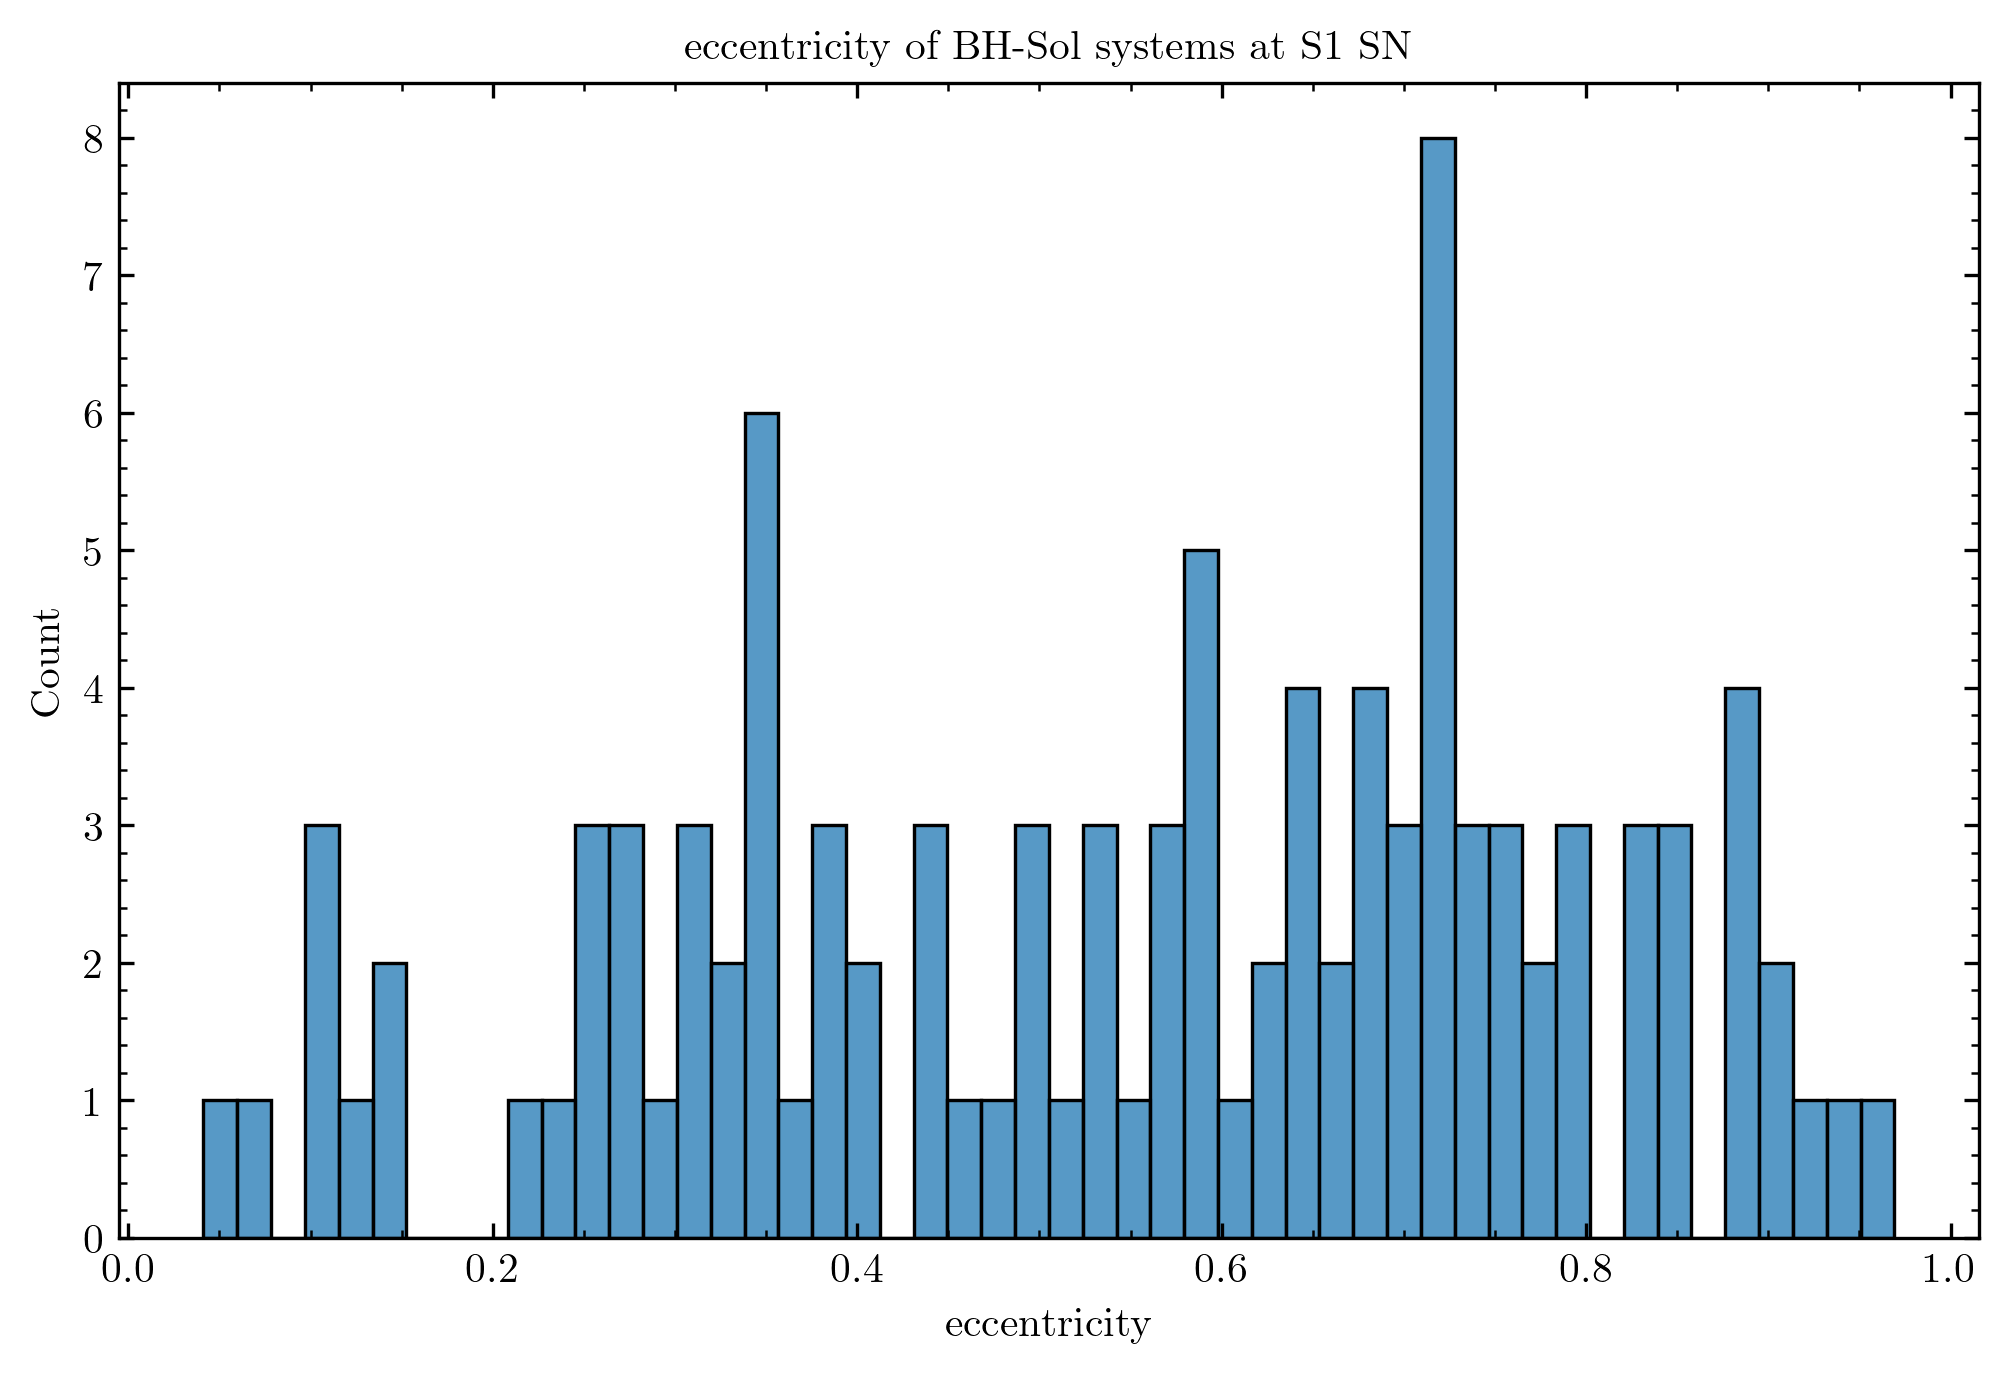

In [139]:
basicColHist(bhSolRows, 'eccentricity')

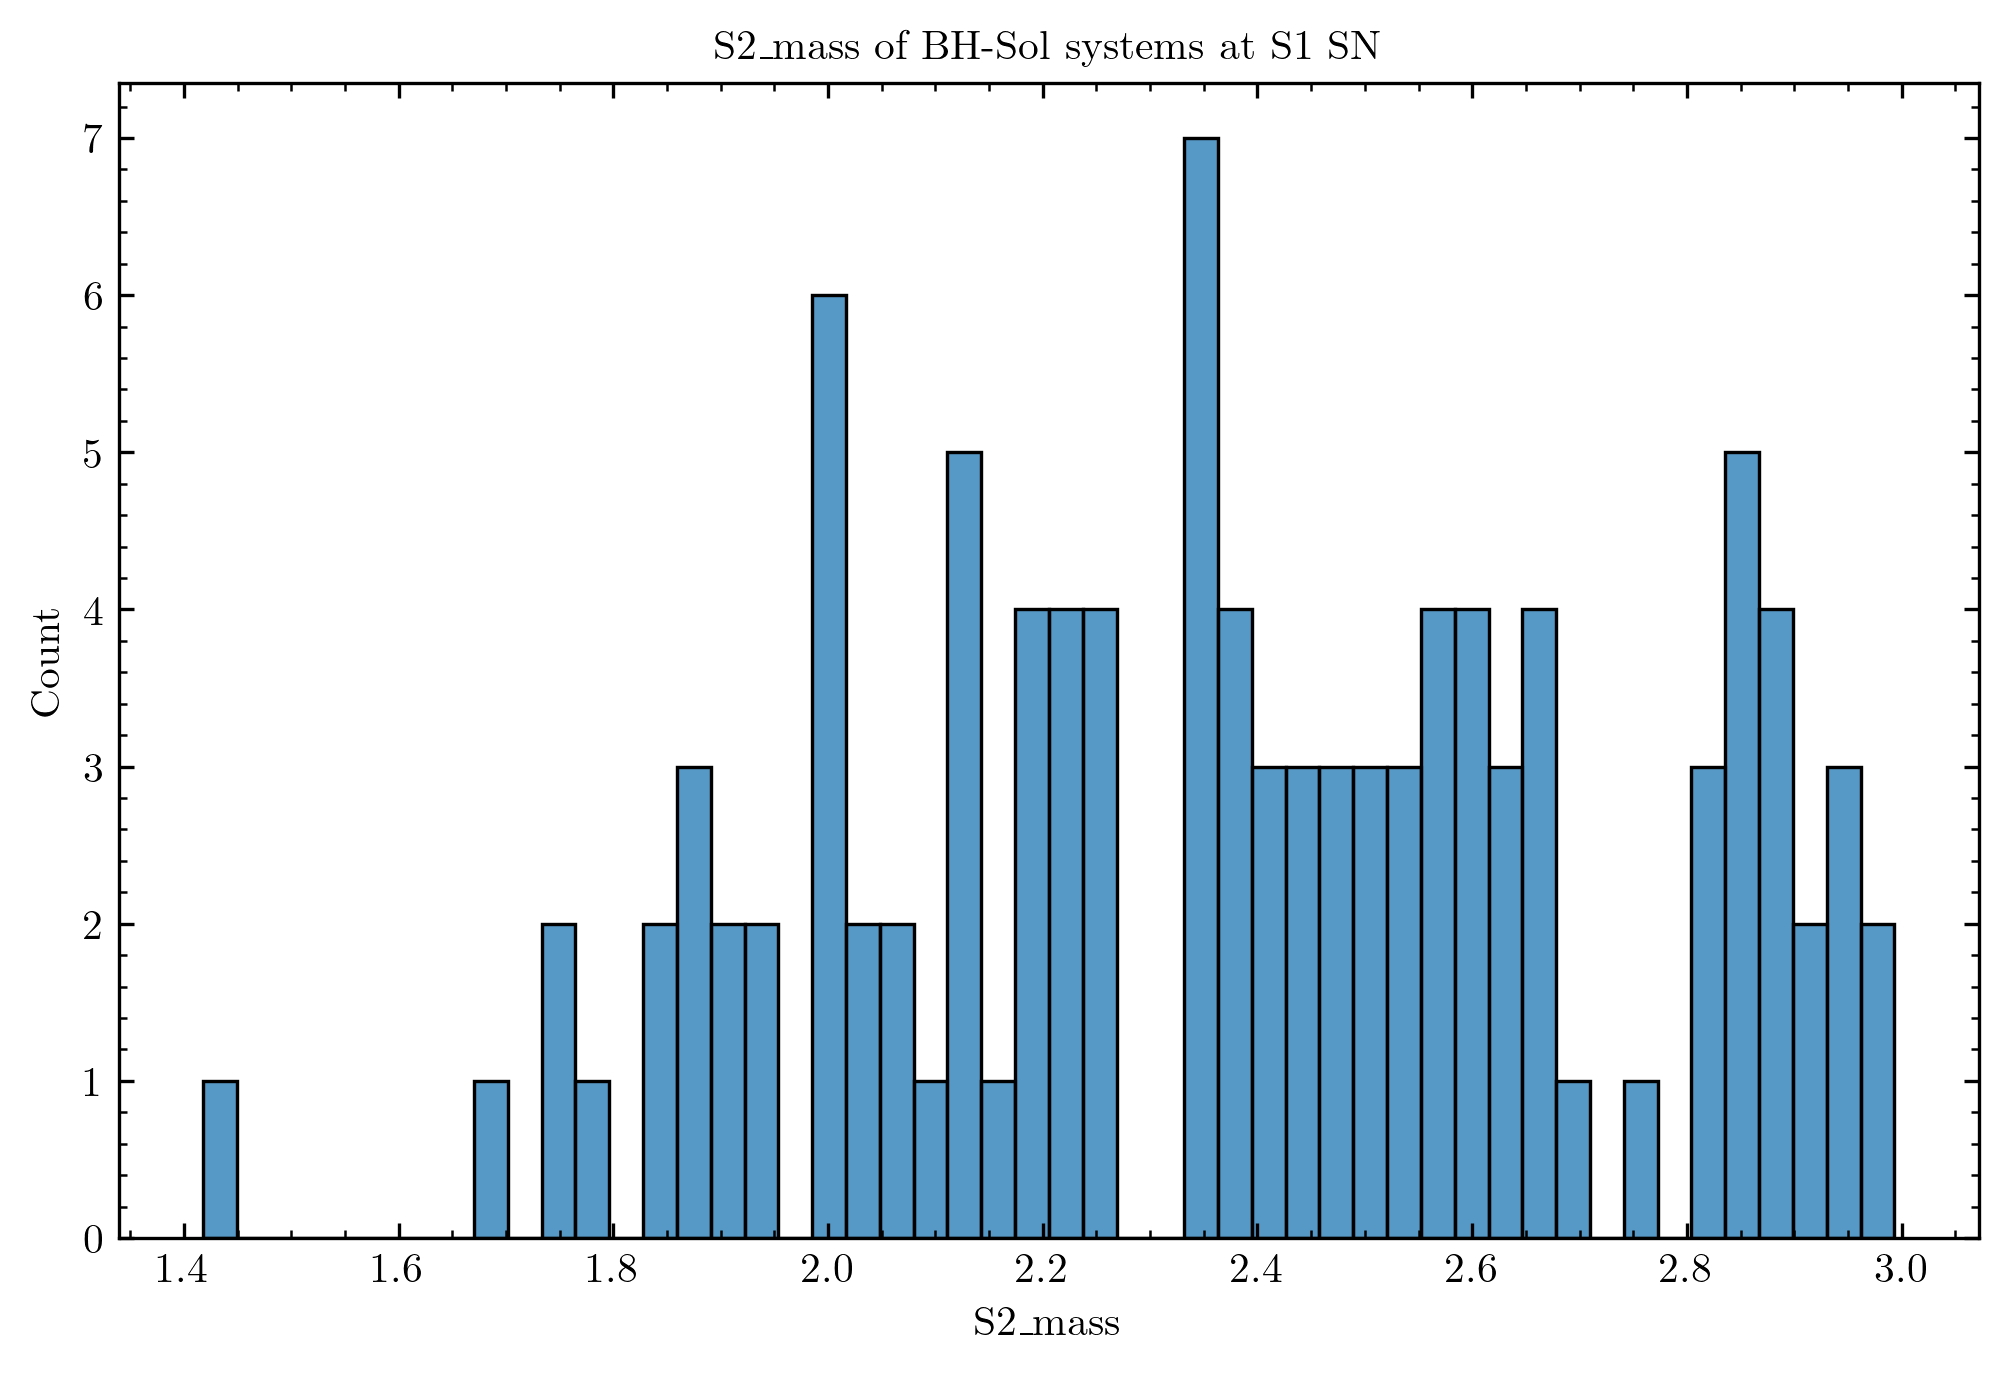

In [140]:
basicColHist(bhSolRows,'S2_mass')

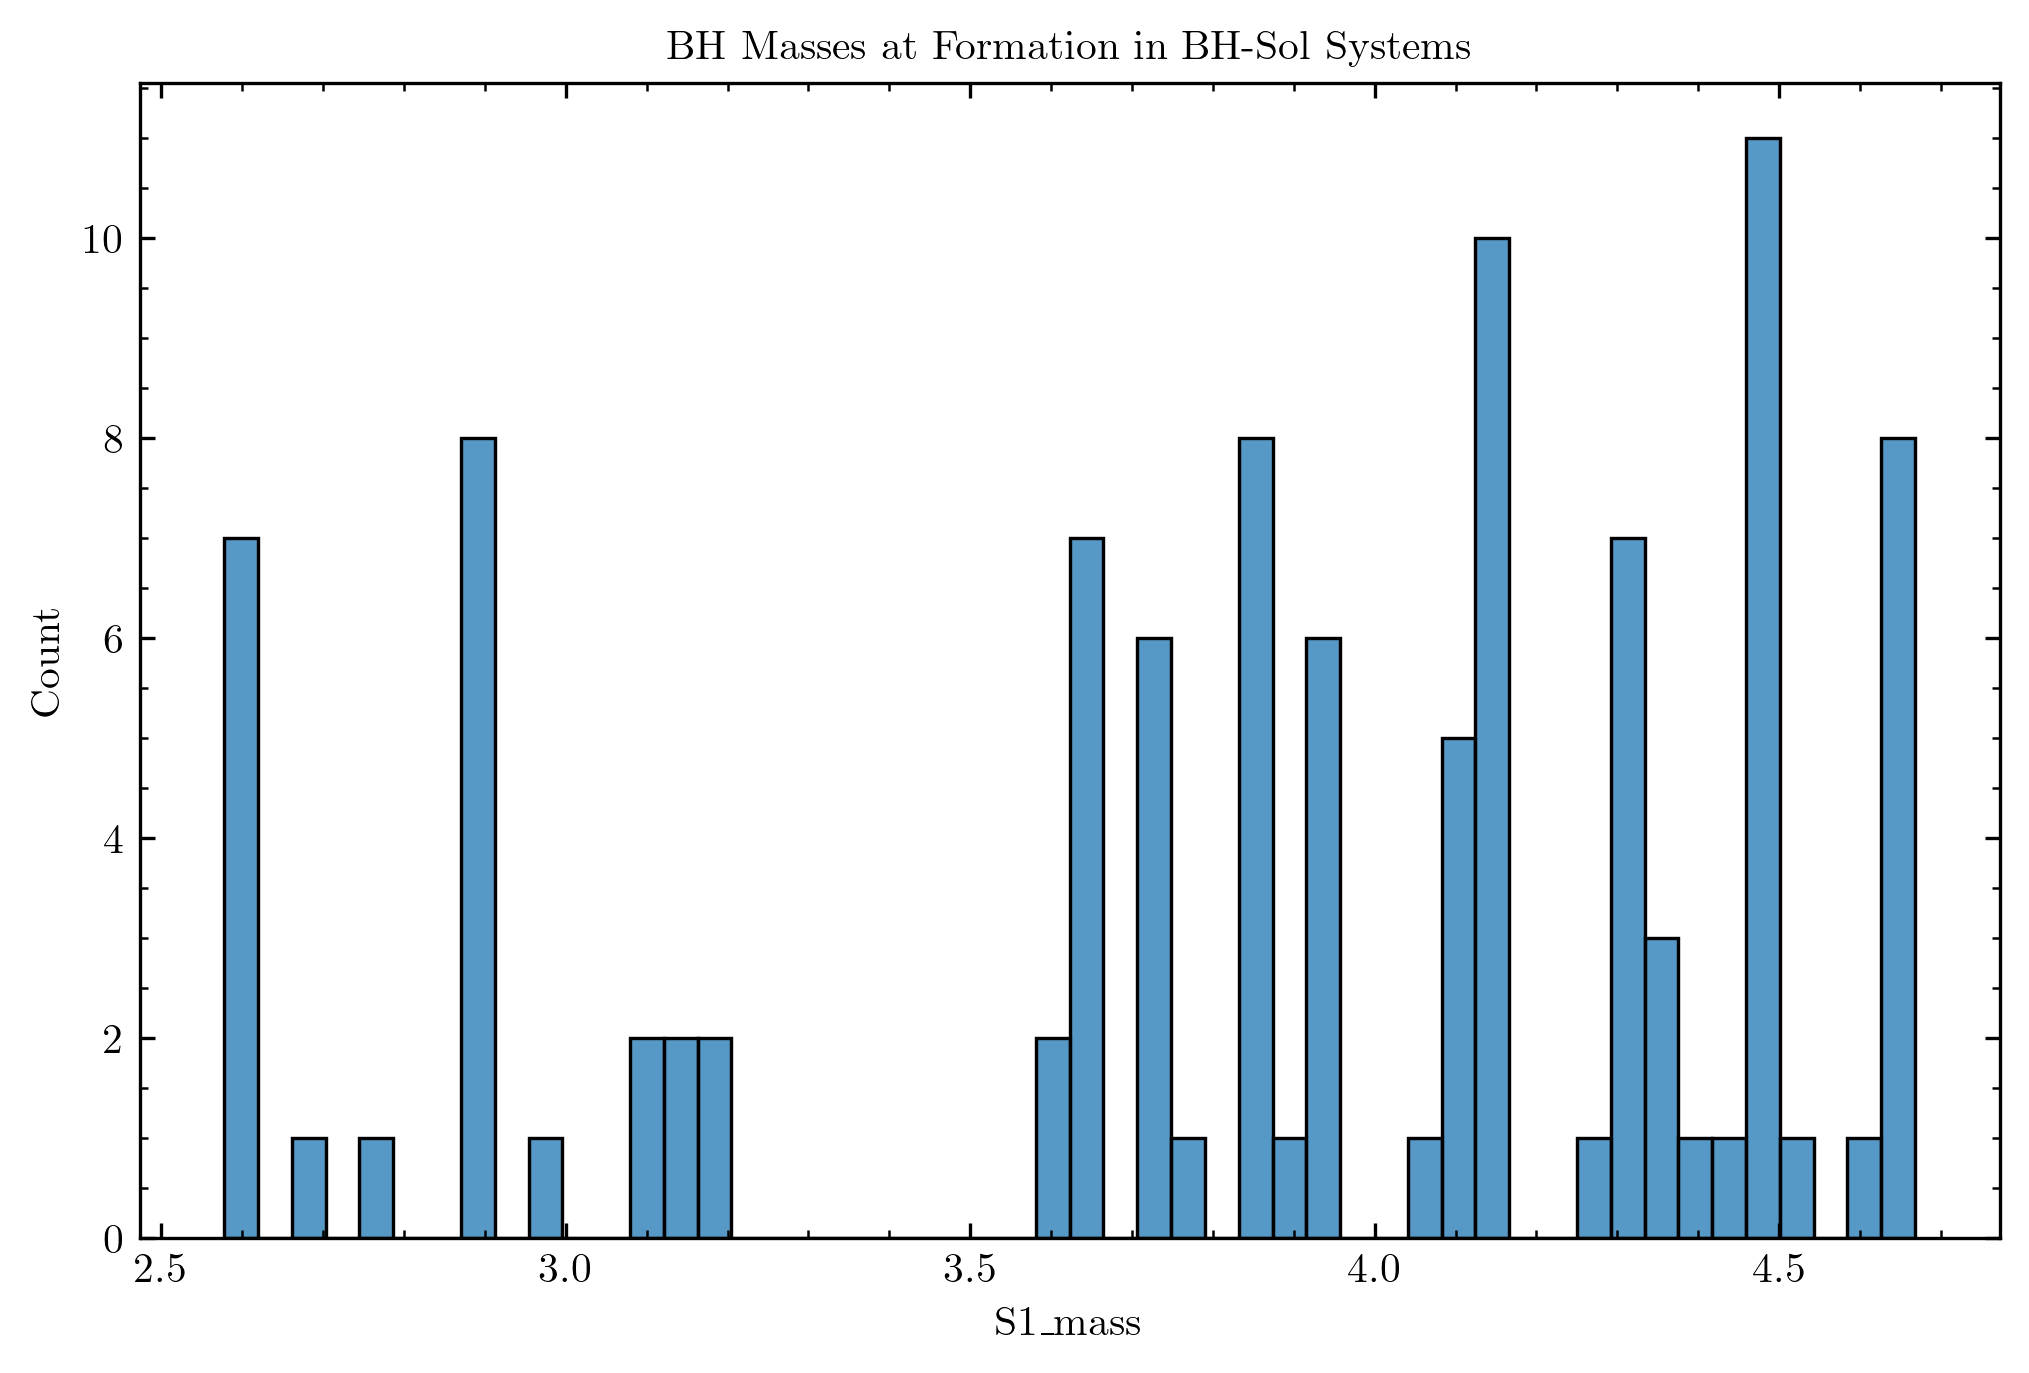

In [141]:
basicColHist(bhSolRows,'S1_mass', title='BH Masses at Formation in BH-Sol Systems')

In [142]:
# basicColHist(bhSolRows,'orbital_period', saveFig=True, savePath=graphSave)

In [143]:
slimOP = bhSolRows[bhSolRows['orbital_period'] < 25]['orbital_period']

In [144]:
# genVarHist(slimOP, title='Orbtial Period in Init BH-Sol Systems', xLabel='Orbital Period (days)', saveFig=True, savePath=graphSave)

In [145]:
# HR_Diagram(bhSolRows,
#            'BhSol',
#            Star_Radius=15)

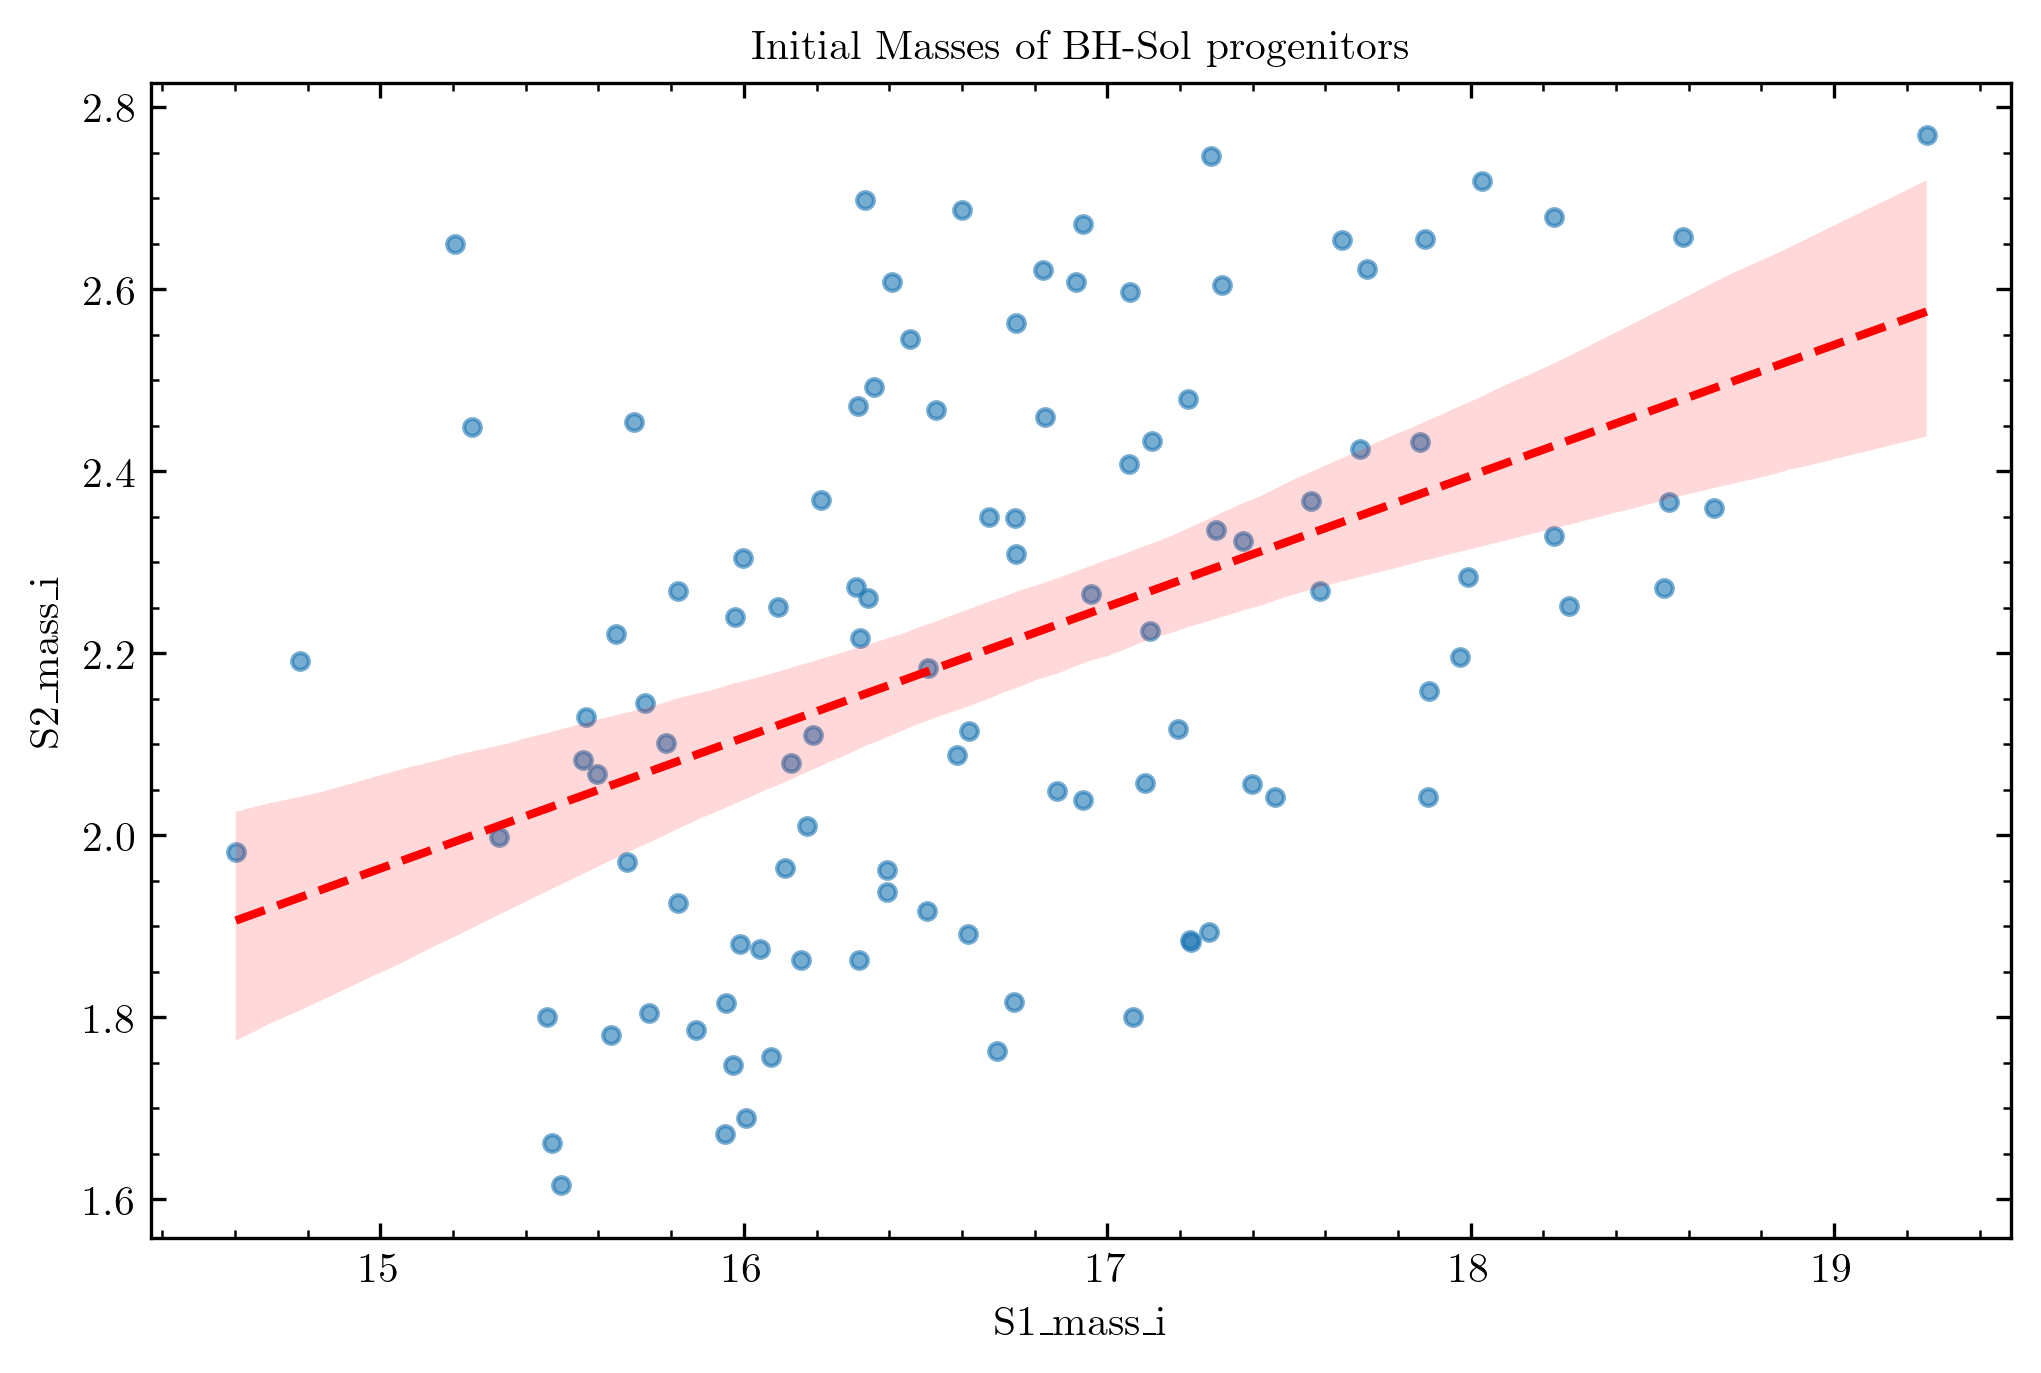

In [146]:
xVsY(df = pOneline, xvar= 'S1_mass_i', yvar='S2_mass_i', title='Initial Masses of BH-Sol progenitors', fit=True, saveFig=False, savePath=graphSave)
# xVsY(df = bhSolRows_Prev, xvar= 'S1_mass', yvar='S2_mass', title='Masses of BH-Sol progenitors', fit=True, saveFig=False, savePath=graphSave)

# xVsY(df = bhSolRows, xvar= 'S1_mass', yvar='S2_mass', title='BH-Sol Masses at Initial Formation', fit=True, saveFig=False, savePath=graphSave)

/tmp/ipykernel_2527327/989365877.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


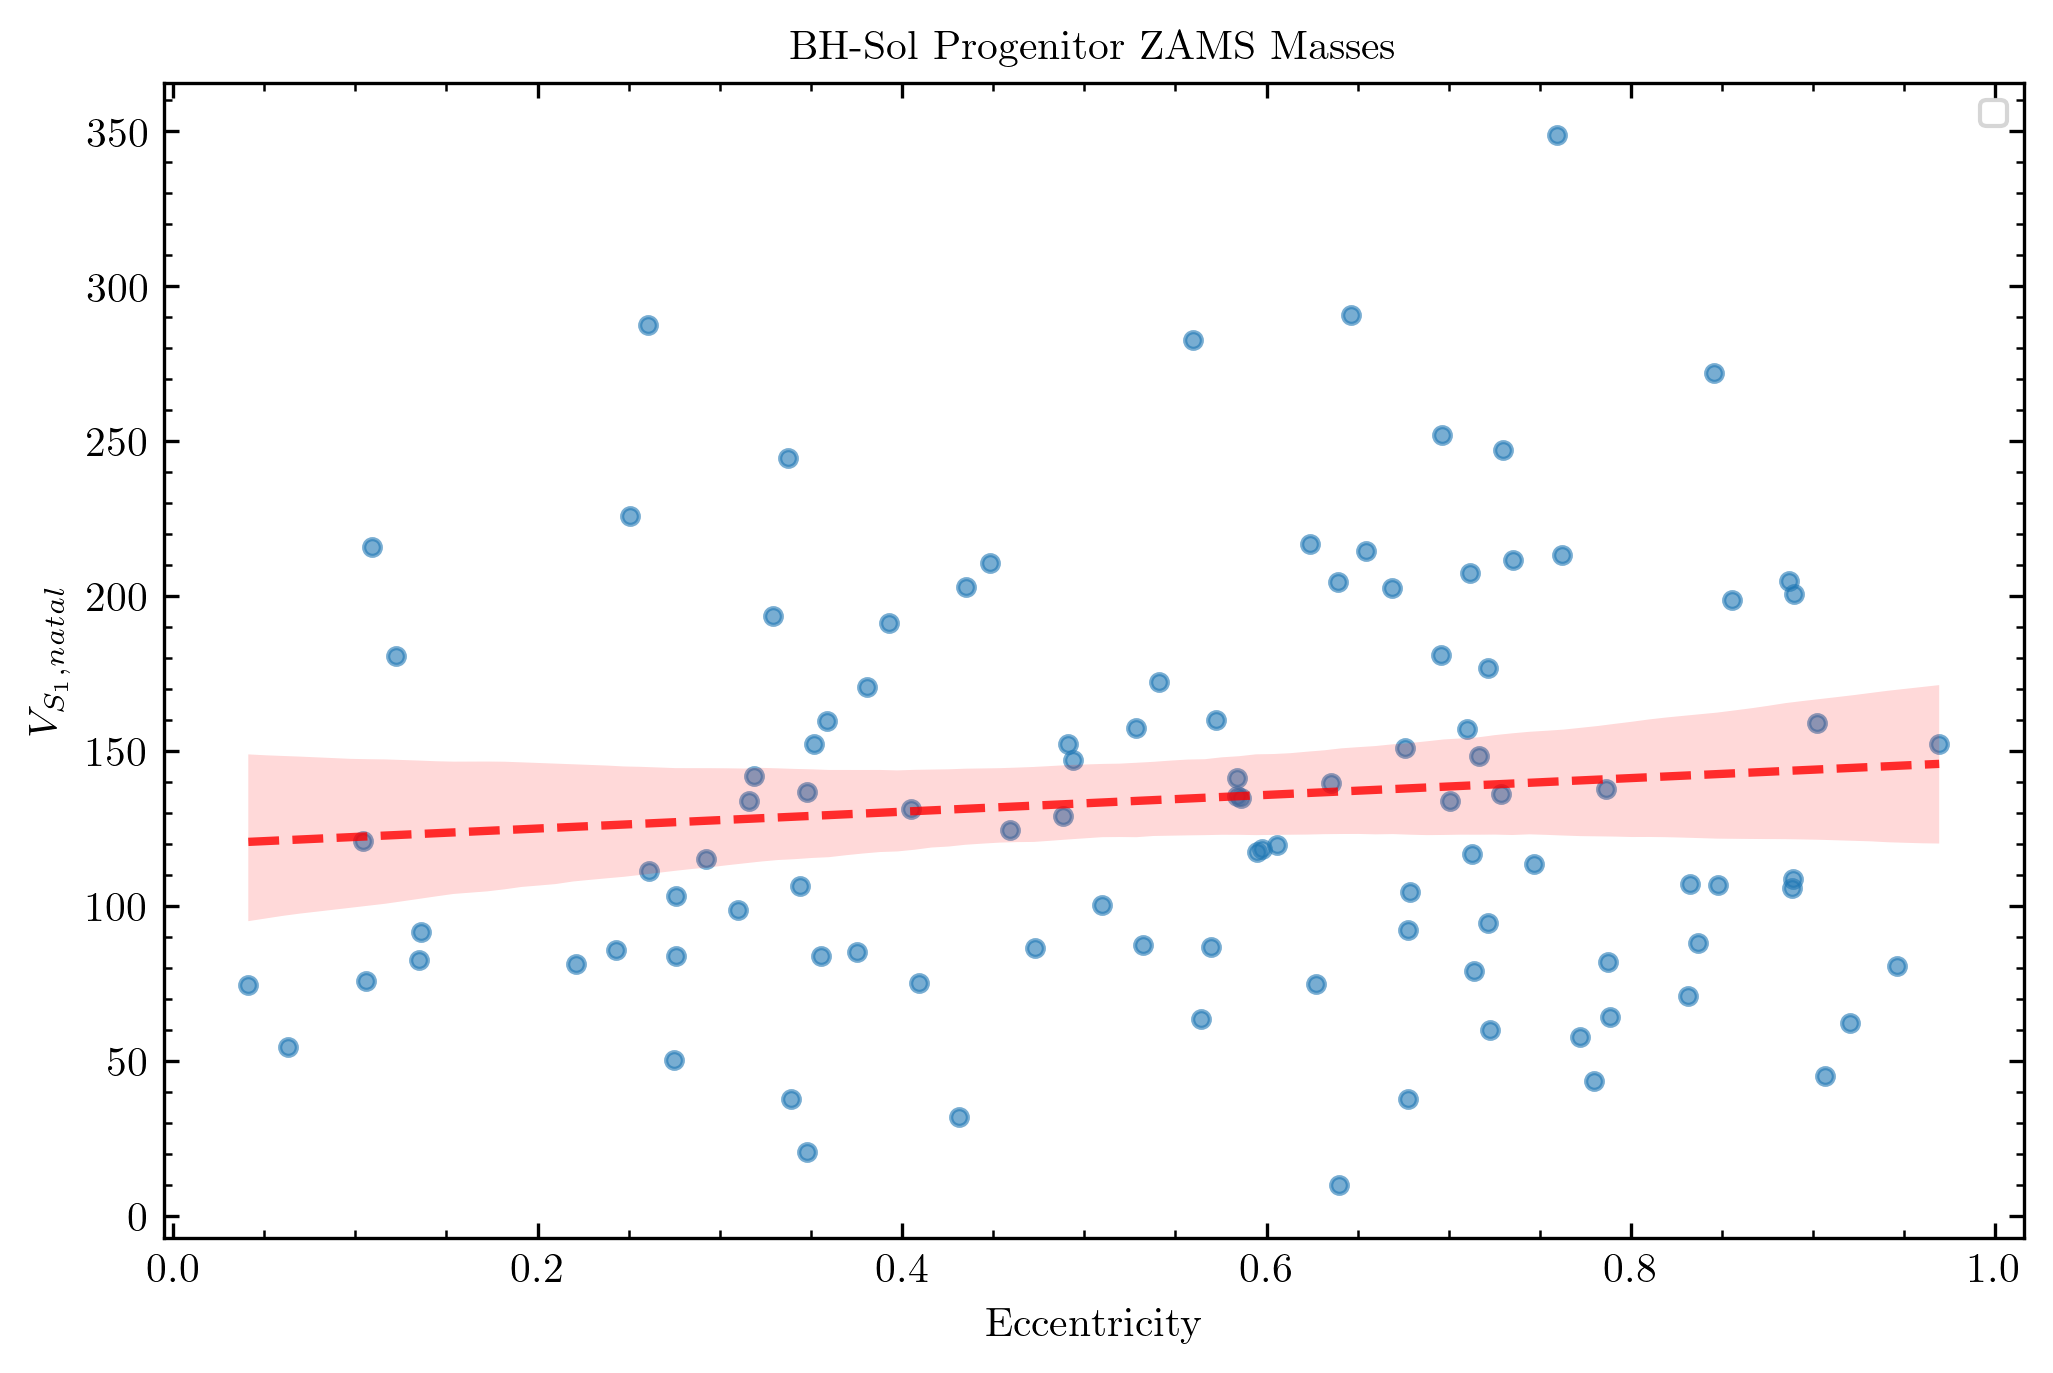

In [147]:
fig, ax = plt.subplots(figsize=(8, 5))

ci = 95

x1,y1 = bhSolRows['eccentricity'],pOneline['S1_natal_kick_velocity']
sns.regplot(x=x1, y=y1, ci=ci, ax=ax,
            line_kws={"color": "red", "linestyle": "--", "linewidth": 2, "alpha": .8},
            scatter_kws={"alpha": 0.6})

plt.legend(frameon=True)
plt.title('BH-Sol Progenitor ZAMS Masses')
plt.ylabel(r'$ V_{S_1, natal}$')
plt.xlabel('Eccentricity')

plt.savefig(graphSave / 'EccVNatalKickV.pgf', bbox_inches='tight')

plt.show()

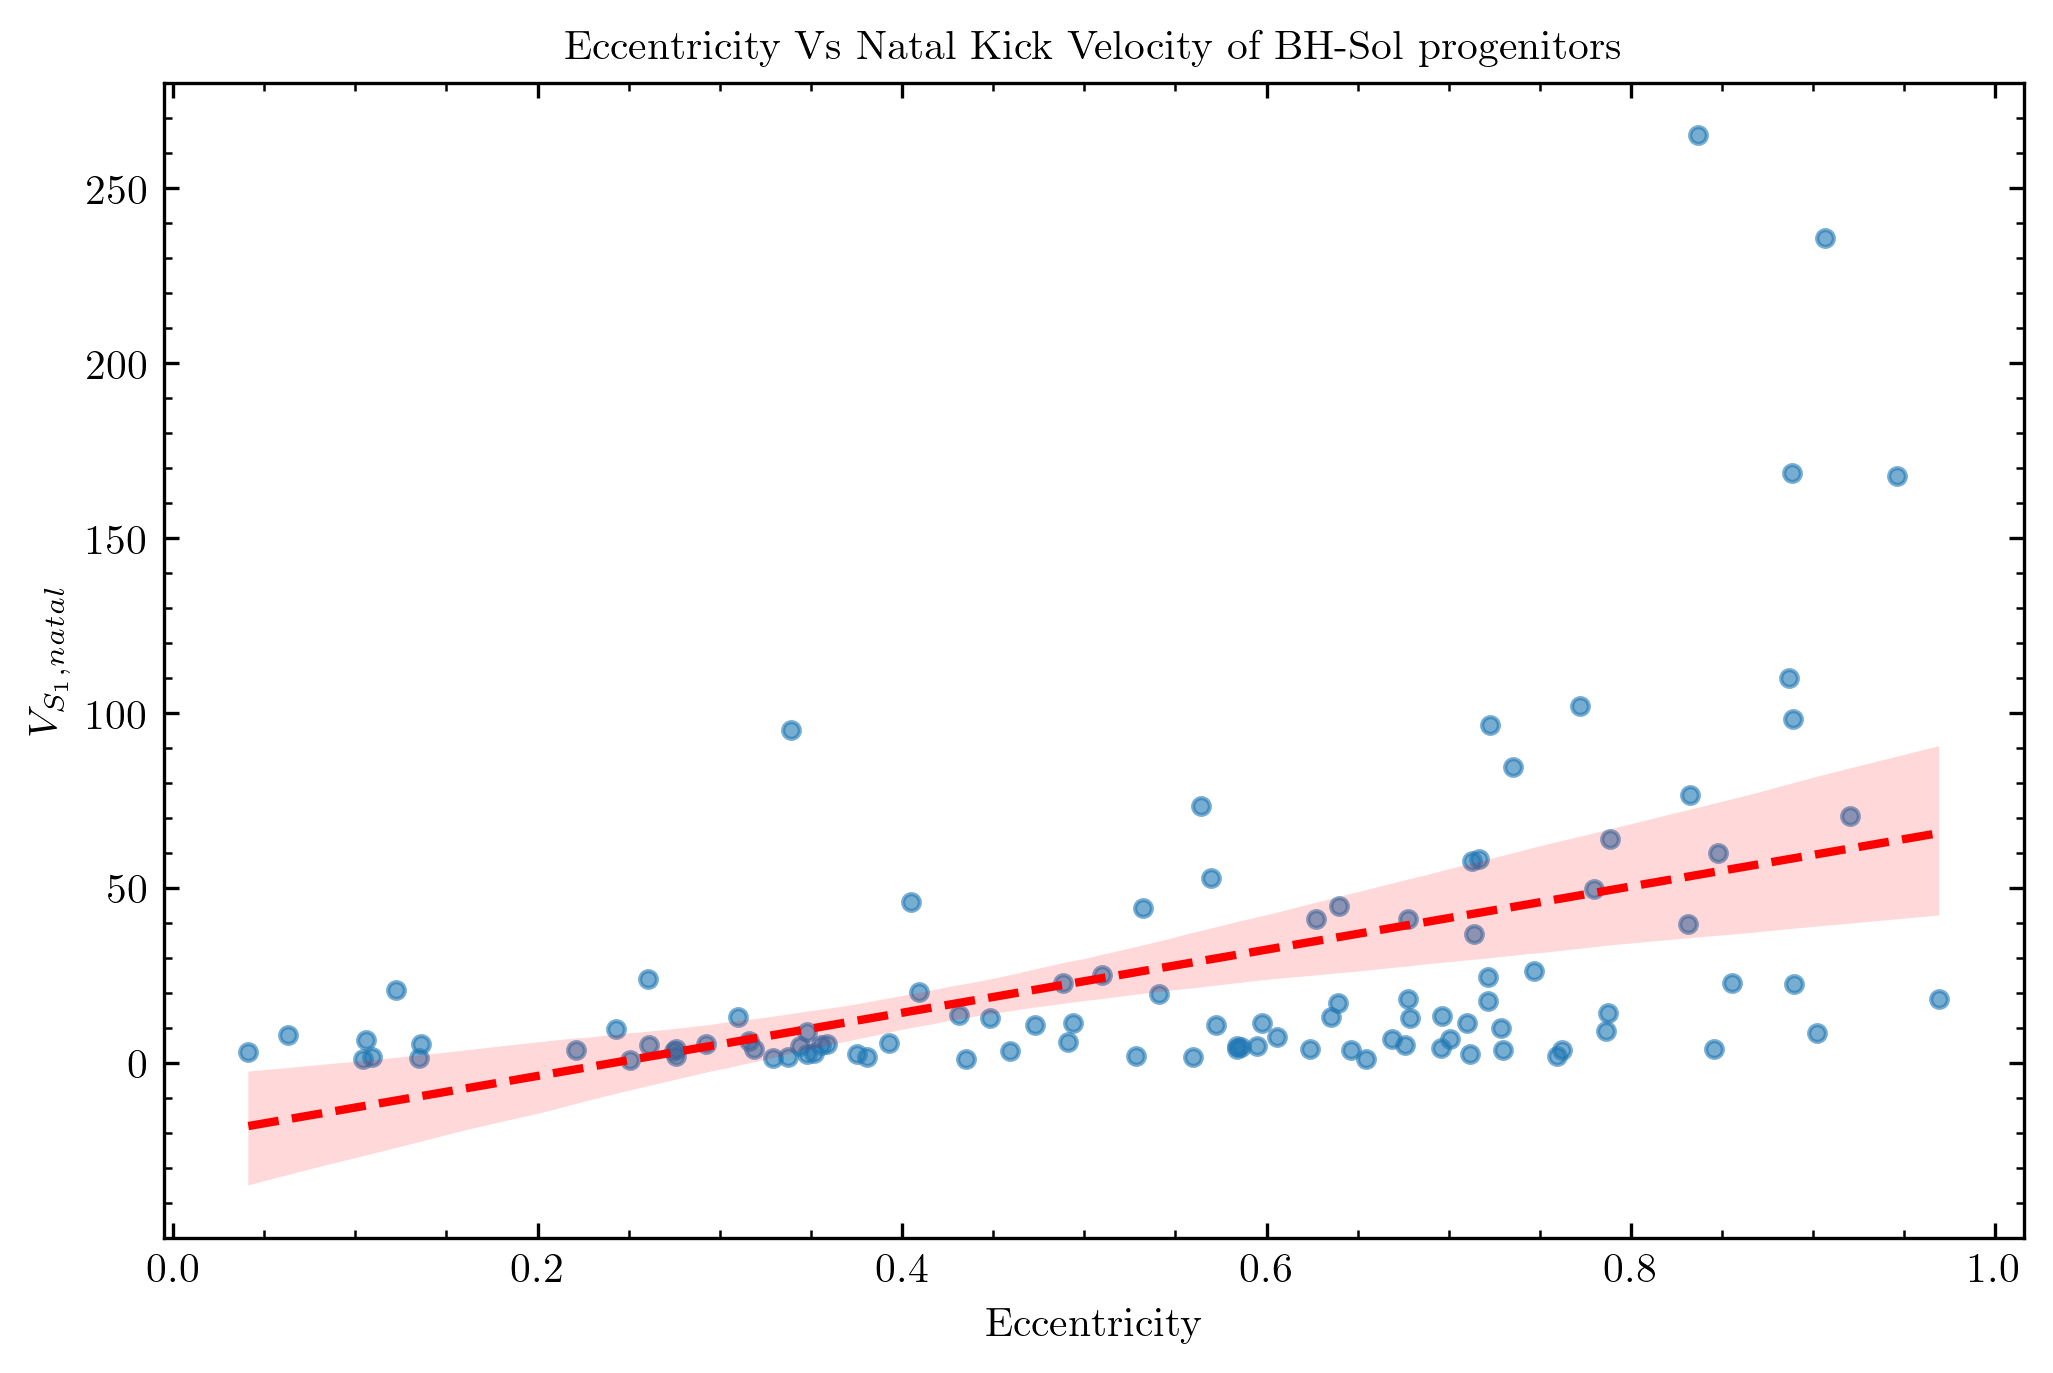

In [148]:
xVsY(xvar= bhSolRows['eccentricity'], yvar=bhSolRows['orbital_period'], title='Eccentricity Vs Natal Kick Velocity of BH-Sol progenitors', xLabel='Eccentricity', yLabel=r'$ V_{S_1, natal}$', fit=True, saveFig=False, savePath=graphSave)


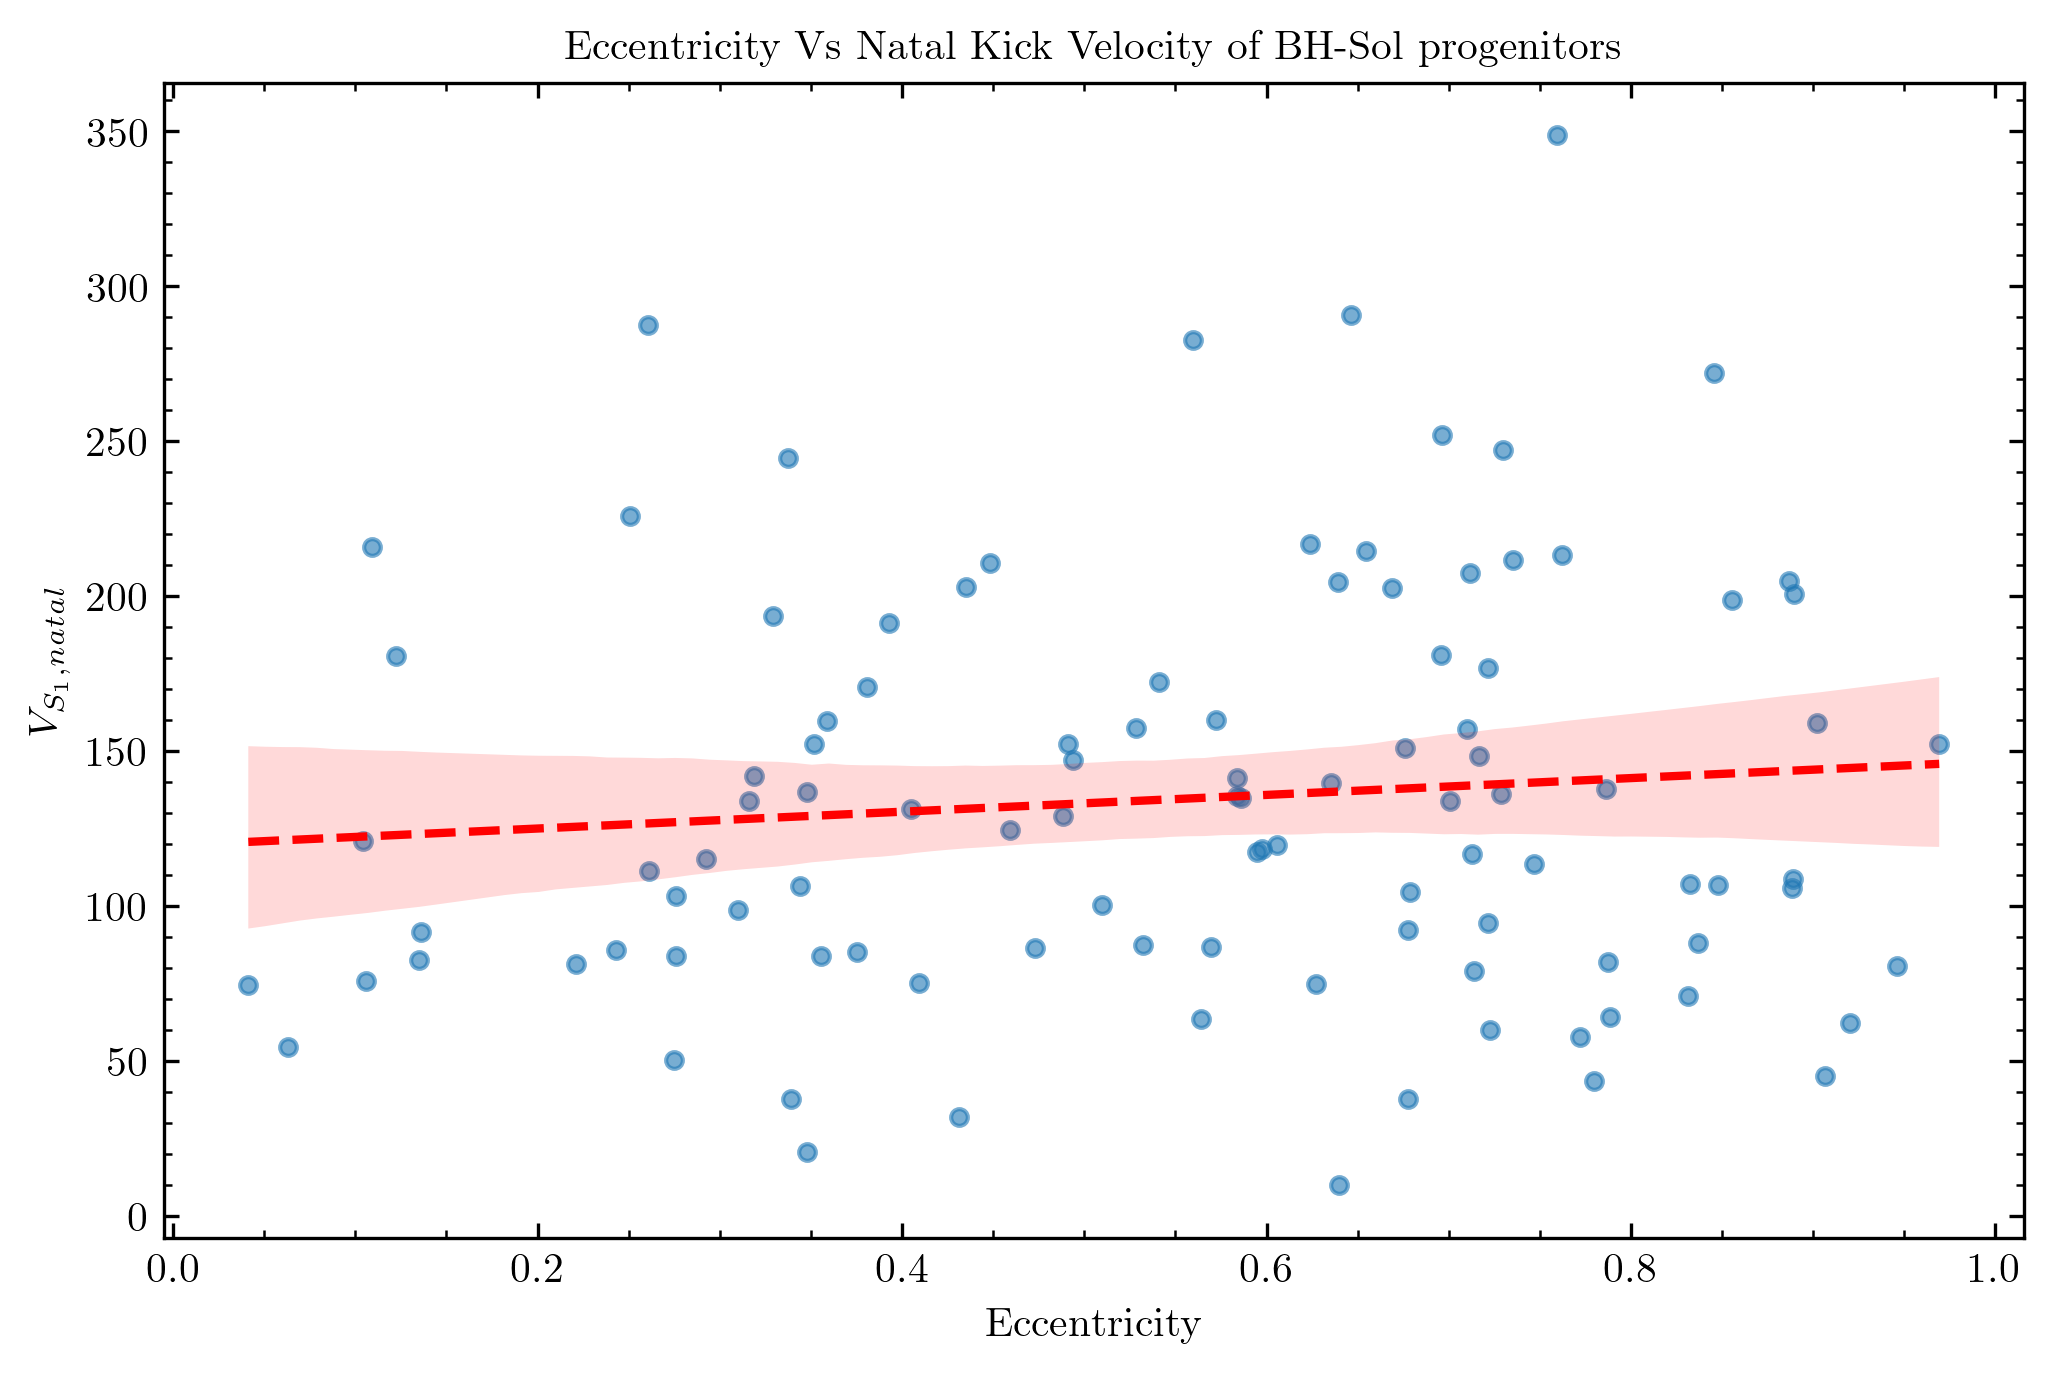

In [149]:
xVsY(xvar= bhSolRows['eccentricity'], yvar=pOneline['S1_natal_kick_velocity'], title='Eccentricity Vs Natal Kick Velocity of BH-Sol progenitors', xLabel='Eccentricity', yLabel=r'$ V_{S_1, natal}$', fit=True, saveFig=True, savePath=graphSave)

In [151]:
bhSolRows_Prev_02Z = bhSolRows_Prev_02Z.loc[bhSolRows_02Z.index.to_list()]

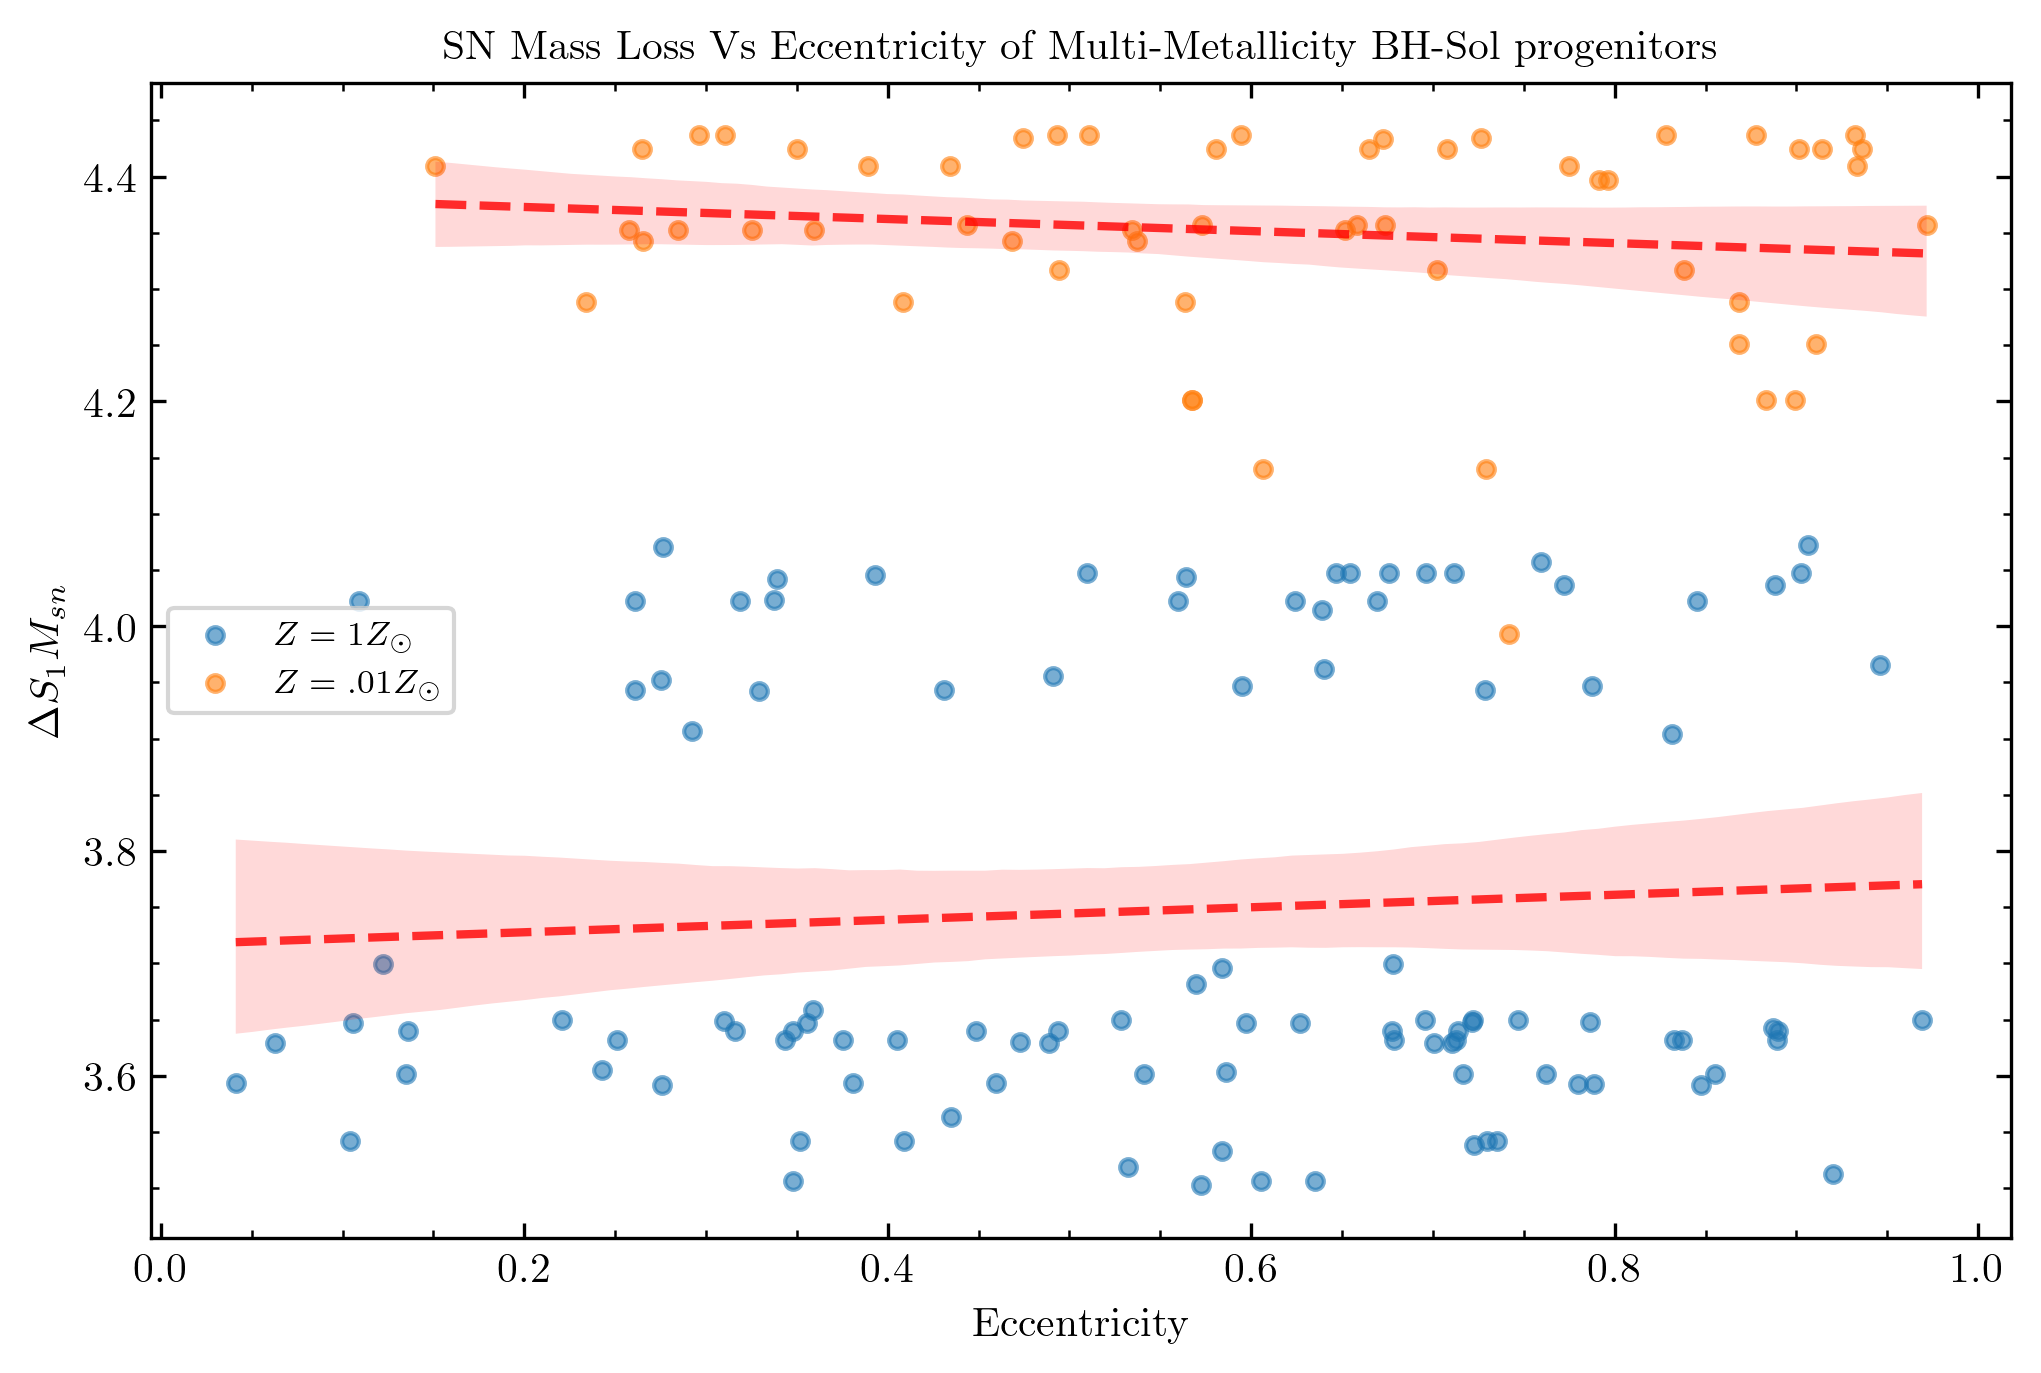

In [152]:
fig, ax = plt.subplots(figsize=(8, 5))

ci = 95

x1,y1 = bhSolRows['eccentricity'],(bhSolRows_Prev['S1_mass'] - bhSolRows['S1_mass'])
x2,y2 = bhSolRows_02Z['eccentricity'],(bhSolRows_Prev_02Z['S1_mass'] - bhSolRows_02Z['S1_mass'])

sns.regplot(x=x1, y=y1, ci=ci, ax=ax,
            line_kws={"color": "red", "linestyle": "--", "linewidth": 2, "alpha": .8},
            scatter_kws={"alpha": 0.6}, label=r"$Z = 1Z_{\odot}$")

sns.regplot(x=x2, y=y2, ci=ci, ax=ax,
            line_kws={"color": "red", "linestyle": "--", "linewidth": 2, "alpha": .8},
            scatter_kws={"alpha": 0.6}, label=r"$Z = .01Z_{\odot}$")

plt.legend(frameon=True)
plt.title('SN Mass Loss Vs Eccentricity of Multi-Metallicity BH-Sol progenitors')
plt.ylabel(r'$\Delta S_1 M_{sn}$')
plt.xlabel('Eccentricity')

plt.savefig(graphSave / 'MLvEcc_MultiMetal.pgf', bbox_inches='tight')

plt.show()

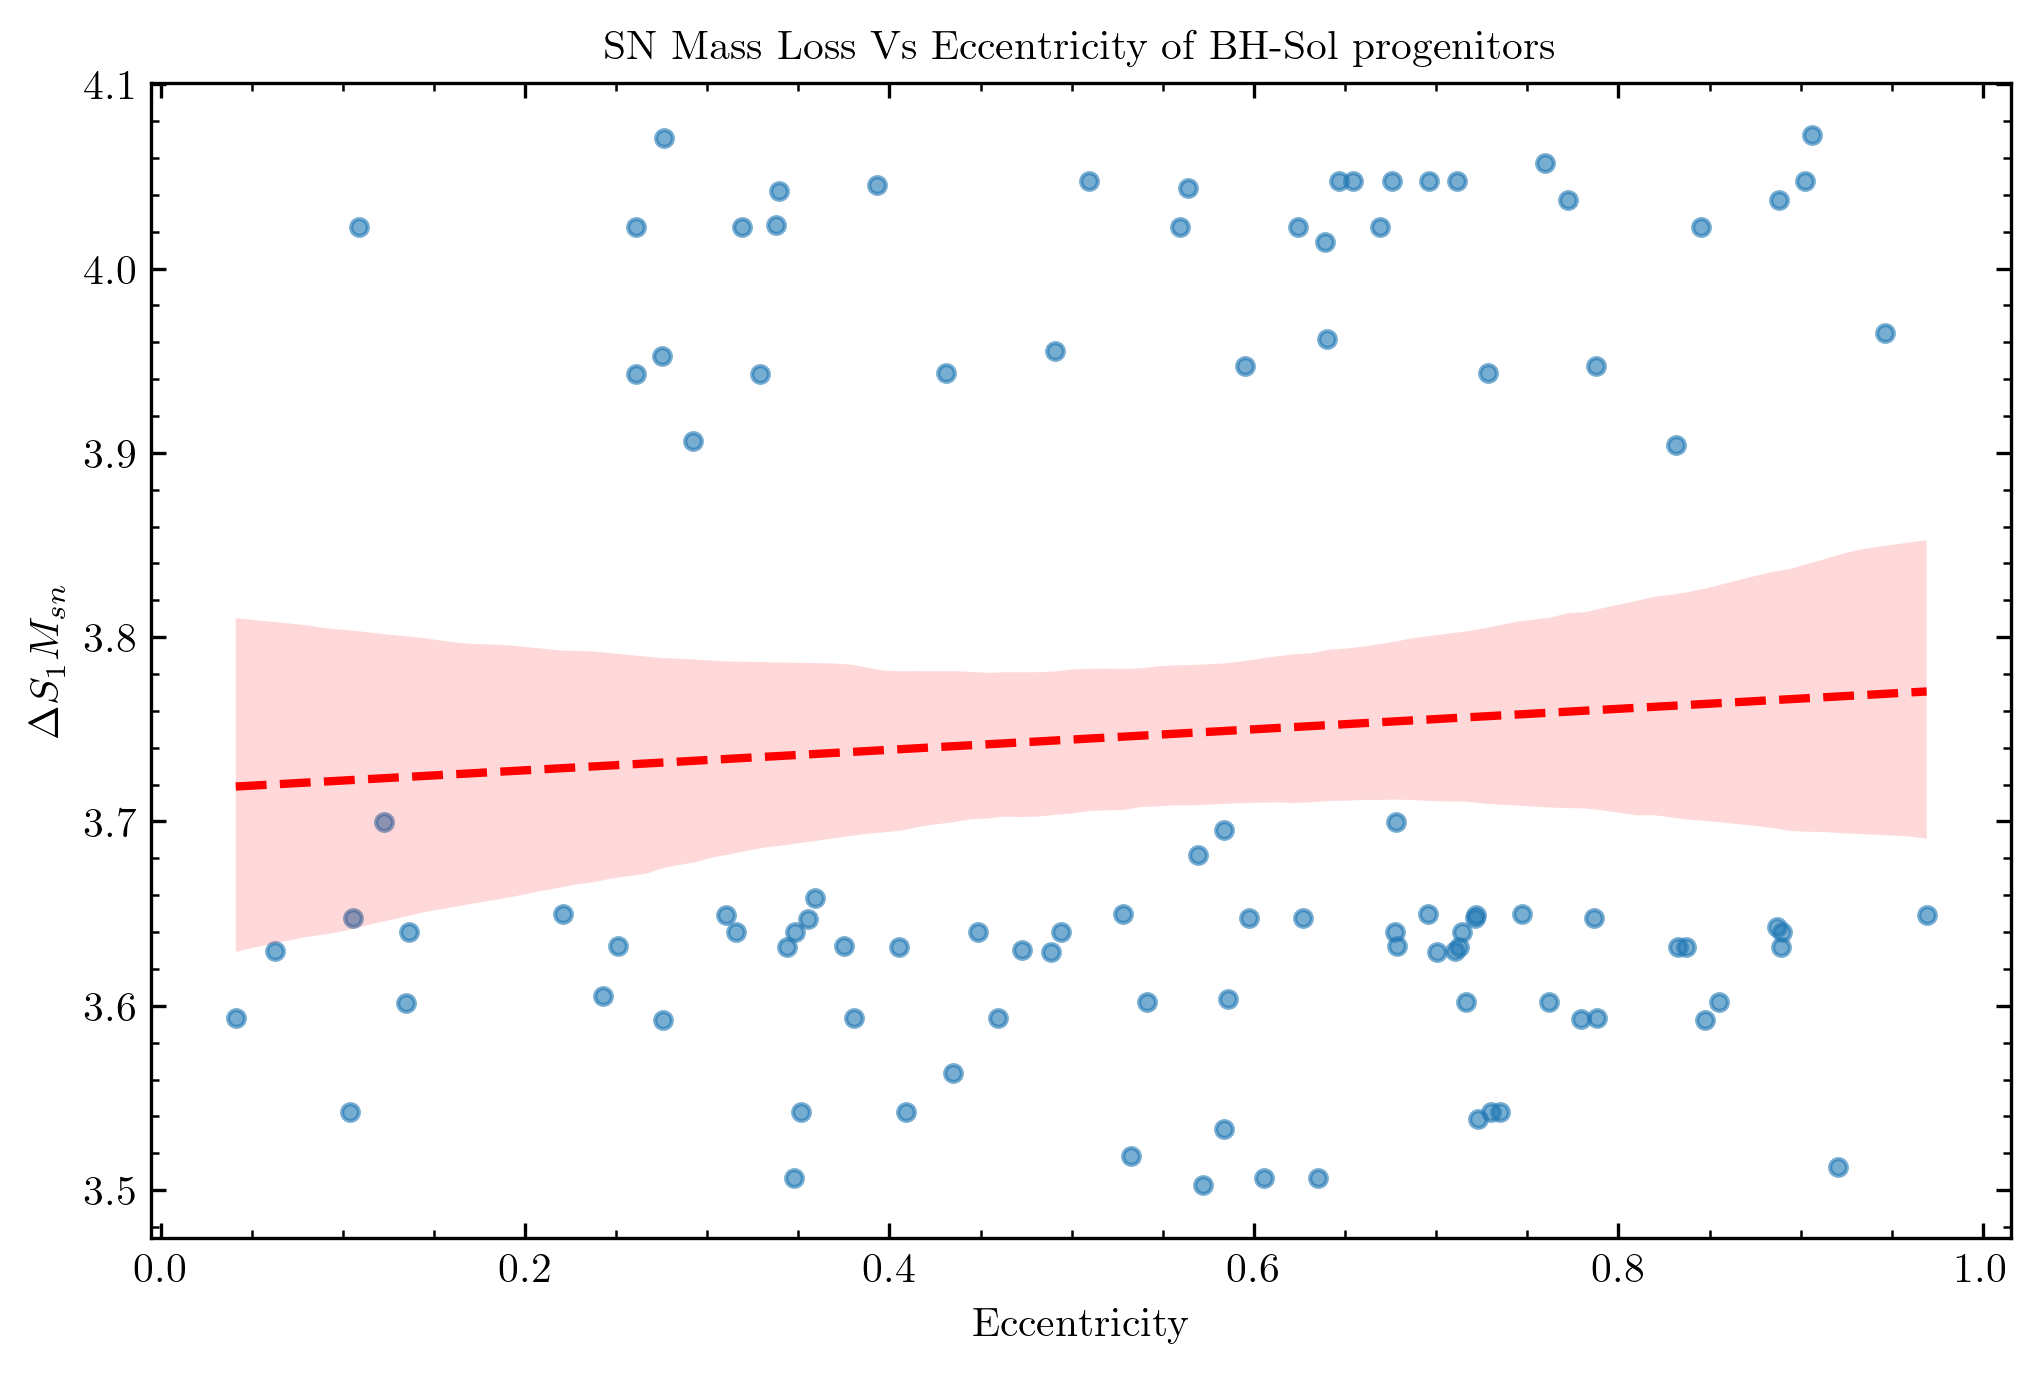

In [153]:
xVsY(xvar= bhSolRows['eccentricity'], yvar=(bhSolRows_Prev['S1_mass'] - bhSolRows['S1_mass']), title='SN Mass Loss Vs Eccentricity of BH-Sol progenitors', yLabel=r'$\Delta S_1 M_{sn}$', xLabel='Eccentricity', fit=True, saveFig=True, savePath=graphSave)

In [154]:
bhSolRows

,binary_index,state,event,time,separation,orbital_period,eccentricity,rl_relative_overflow_1,rl_relative_overflow_2,lg_mtransfer_rate,...,S2_conv_env_turnover_time_l_t,S2_envelope_binding_energy,S2_mass_conv_reg_fortides,S2_thickness_conv_reg_fortides,S2_radius_conv_reg_fortides,S2_lambda_CE_1cent,S2_lambda_CE_10cent,S2_lambda_CE_30cent,S2_lambda_CE_pure_He_star_10cent,deltaM1SN
0,98167,detached,NaN,8.999790e+09,15.592295,2.759667,0.351460,NaN,NaN,NaN,...,0.000000,-1.060802e+49,1.376460e-09,0.003673,1.596058,1.059250,1.059250,1.059250,1.059250,3.542394
1,164933,detached,NaN,5.320878e+09,23.548169,5.665033,0.393018,NaN,NaN,NaN,...,0.000000,-1.306797e+49,1.275745e-09,0.003705,1.749940,1.087898,1.087898,1.087898,1.087898,4.045273
2,421025,detached,NaN,8.501130e+09,56.874522,19.815499,0.541184,NaN,NaN,NaN,...,0.000000,-1.074448e+49,1.368844e-09,0.003717,1.604894,1.060897,1.060897,1.060897,1.060897,3.601848
3,432008,detached,NaN,7.629853e+07,6.833317,0.876181,0.250778,NaN,NaN,NaN,...,2289.310733,-5.554021e+48,4.375370e-08,0.018593,1.386301,0.976688,0.976688,0.976688,0.976688,3.632313
4,469540,detached,NaN,4.671309e+09,30.960643,7.931873,0.062861,NaN,NaN,NaN,...,0.000000,-1.389527e+49,1.257137e-09,0.003917,1.801025,1.096518,1.096518,1.096518,1.096518,3.629659
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,9869876,detached,NaN,7.958286e+09,176.651172,109.989868,0.886831,NaN,NaN,NaN,...,0.000000,-1.093747e+49,1.358731e-09,0.003729,1.617445,1.063203,1.063203,1.063203,1.063203,3.642677
103,9893810,detached,NaN,5.797456e+09,47.100819,13.746755,0.431066,NaN,NaN,NaN,...,0.000000,-1.542464e+49,1.212454e-09,0.003906,1.882450,1.113239,1.113239,1.113239,1.113239,3.943543
104,9898281,detached,NaN,6.978108e+09,28.385943,6.730866,0.105824,NaN,NaN,NaN,...,0.000000,-1.483731e+49,1.233944e-09,0.003928,1.855052,1.106384,1.106384,1.106384,1.106384,3.647436
105,9912445,detached,NaN,3.801350e+09,84.011404,36.878780,0.713982,NaN,NaN,NaN,...,0.000000,-9.481873e+48,1.490166e-09,0.003777,1.534551,1.042847,1.042847,1.042847,1.042847,3.640189


In [155]:
bhSolRows_Prev

,binary_index,state,event,time,separation,orbital_period,eccentricity,rl_relative_overflow_1,rl_relative_overflow_2,lg_mtransfer_rate,...,S2_conv_env_turnover_time_l_b,S2_conv_env_turnover_time_l_t,S2_envelope_binding_energy,S2_mass_conv_reg_fortides,S2_thickness_conv_reg_fortides,S2_radius_conv_reg_fortides,S2_lambda_CE_1cent,S2_lambda_CE_10cent,S2_lambda_CE_30cent,S2_lambda_CE_pure_He_star_10cent
0,98167,detached,CC1,8.999790e+09,12.487912,1.599223,0.0,-0.938482,-0.530065,NaN,...,0.000000,0.000000,-1.060802e+49,1.376460e-09,0.003673,1.596058,1.059250,1.059250,1.059250,1.059250
1,164933,detached,CC1,5.320878e+09,14.485467,2.071923,0.0,-0.917802,-0.591177,NaN,...,0.000000,0.000000,-1.306797e+49,1.275745e-09,0.003705,1.749940,1.087898,1.087898,1.087898,1.087898
2,421025,detached,CC1,8.501130e+09,87.287180,30.046101,0.0,-0.991358,-0.933389,NaN,...,0.000000,0.000000,-1.074448e+49,1.368844e-09,0.003717,1.604894,1.060897,1.060897,1.060897,1.060897
3,432008,detached,CC1,7.629853e+07,8.534946,0.951980,0.0,-0.918061,-0.333092,NaN,...,0.000114,2289.310733,-5.554021e+48,4.375370e-08,0.018593,1.386301,0.976688,0.976688,0.976688,0.976688
4,469540,detached,CC1,4.671309e+09,32.375258,6.763024,0.0,-0.975919,-0.811924,NaN,...,0.000000,0.000000,-1.389527e+49,1.257137e-09,0.003917,1.801025,1.096518,1.096518,1.096518,1.096518
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,9869876,detached,CC1,7.958286e+09,120.058567,48.794430,0.0,-0.993813,-0.951652,NaN,...,0.000000,0.000000,-1.093747e+49,1.358731e-09,0.003729,1.617445,1.063203,1.063203,1.063203,1.063203
103,9893810,detached,CC1,5.797456e+09,26.981636,4.817070,0.0,-0.969304,-0.759960,NaN,...,0.000000,0.000000,-1.542464e+49,1.212454e-09,0.003906,1.882450,1.113239,1.113239,1.113239,1.113239
104,9898281,detached,CC1,6.978108e+09,30.711511,6.108189,0.0,-0.974550,-0.796309,NaN,...,0.000000,0.000000,-1.483731e+49,1.233944e-09,0.003928,1.855052,1.106384,1.106384,1.106384,1.106384
105,9912445,detached,CC1,3.801350e+09,25.066508,4.719992,0.0,-0.970987,-0.774145,NaN,...,0.000000,0.000000,-9.481873e+48,1.490166e-09,0.003777,1.534551,1.042847,1.042847,1.042847,1.042847


In [156]:
(bhSolRows_Prev['S1_mass'] -bhSolRows['S1_mass'])

0      3.542394
1      4.045273
2      3.601848
3      3.632313
4      3.629659
         ...   
102    3.642677
103    3.943543
104    3.647436
105    3.640189
106    3.542494
Name: S1_mass, Length: 105, dtype: float64

In [157]:
# xVsY(useDF=False, xvar=pOneline['S1_mass_i'], yvar=bhSolRows['eccentricity'], fit=True)

In [158]:
# fig, ax = plt.subplots(figsize=(8,5))

# var = 'S2_mass_i'
# sns.histplot(pOneline[var], bins=50, ax=ax)

# title = f'{var} of BH-Sol Systems'

# ax.set_title(title)
# ax.set_xlabel(var)
# ax.set_ylabel('Count')

# clean_name = title.replace(' ', '_').replace('/', '-') + '.pgf'
# plt.savefig(graphSave / clean_name, bbox_inches='tight')

# plt.show()

In [159]:
# fig, ax = plt.subplots(figsize=(8,5))

# var = 'S1_mass_i'
# sns.histplot(pOneline[var], bins=50, ax=ax)

# title = f'{var} of BH-Sol Systems'

# ax.set_title(title)
# ax.set_xlabel(var)
# ax.set_ylabel('Count')

# clean_name = title.replace(' ', '_').replace('/', '-') + '.pgf'
# plt.savefig(graphSave / clean_name, bbox_inches='tight')

# plt.show()

[ 0.14380859 -0.19347512]
[ 0.14874042 -0.15020399]


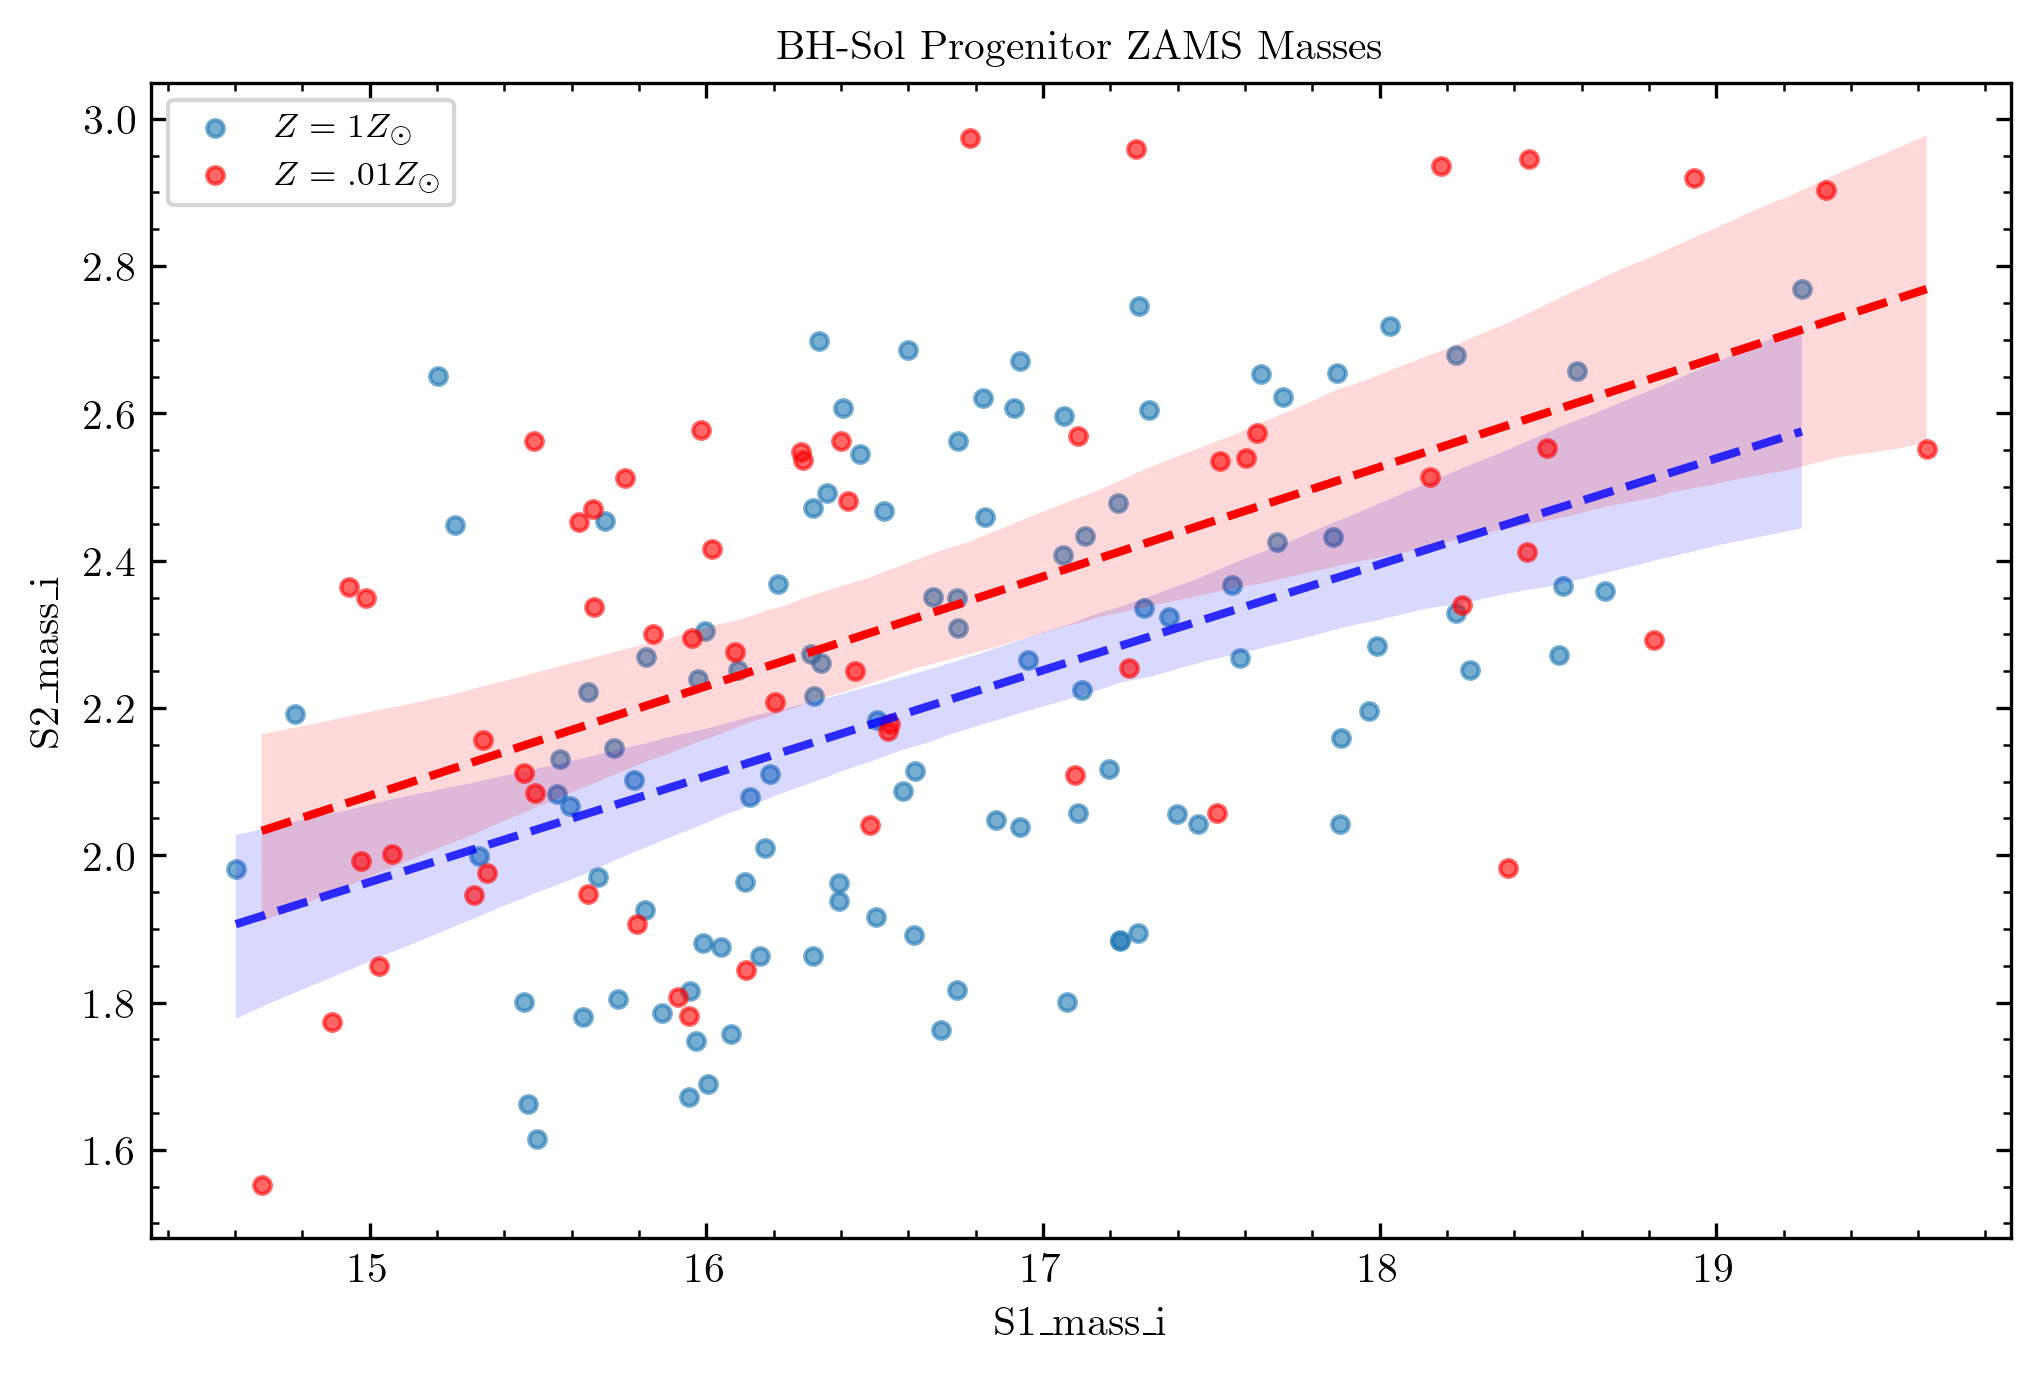

In [160]:
fig, ax = plt.subplots(figsize=(8, 5))

ci = 95

x1,y1 = pOneline['S1_mass_i'],pOneline['S2_mass_i']
x2,y2 = pOneline_02Z['S1_mass_i'],pOneline_02Z['S2_mass_i']

print(np.polyfit(x1,y1, 1))
print(np.polyfit(x2,y2, 1))

sns.regplot(x=x1, y=y1, ci=ci, ax=ax,
            line_kws={"color": "blue", "linestyle": "--", "linewidth": 2, "alpha": .8},
            scatter_kws={"alpha": 0.6}, label=r"$Z = 1Z_{\odot}$")

sns.regplot(x=x2, y=y2, ci=ci, ax=ax, color= 'red',
            line_kws={"color": "red", "linestyle": "--", "linewidth": 2},
            scatter_kws={"alpha": 0.6}, label=r"$Z = .01 Z_{\odot}$")


plt.legend(frameon=True)
plt.title('BH-Sol Progenitor ZAMS Masses')

plt.savefig(graphSave / 'ZsunVs_e02Zsun.pgf', format ='pgf', transparent =True, bbox_inches='tight')

plt.show()

[0.04621293 2.20081145]
[0.26727867 1.67415401]


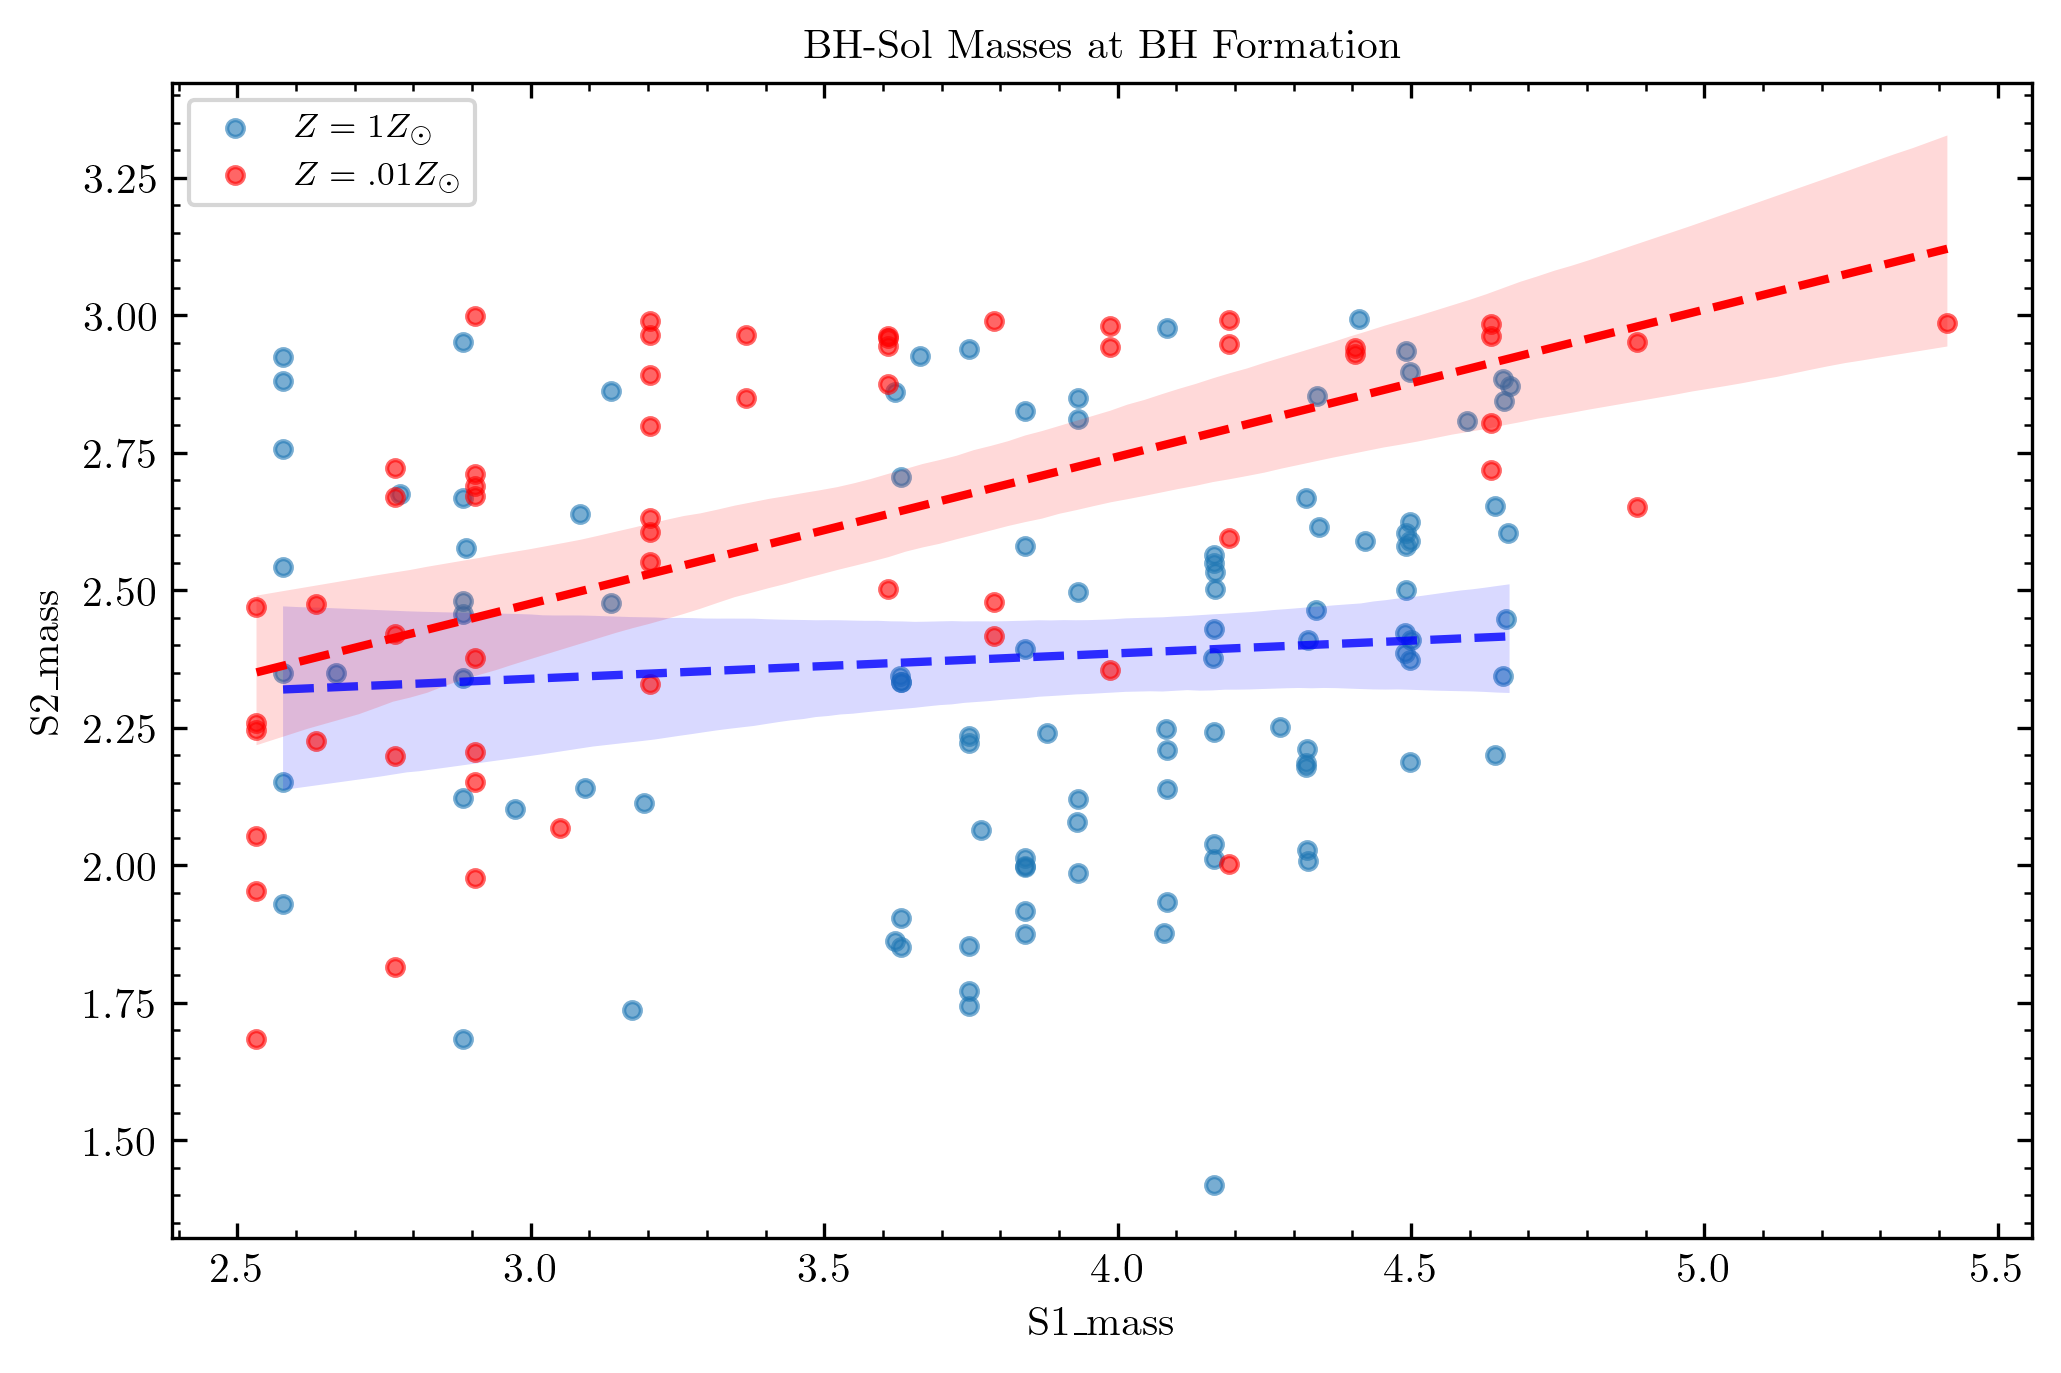

In [161]:
fig, ax = plt.subplots(figsize=(8, 5))

ci = 95

x1,y1 = bhSolRows['S1_mass'],bhSolRows['S2_mass']
x2,y2 = bhSolRows_02Z['S1_mass'],bhSolRows_02Z['S2_mass']

print(np.polyfit(x1,y1, 1))
print(np.polyfit(x2,y2, 1))

sns.regplot(x=x1, y=y1, ci=ci, ax=ax,
            line_kws={"color": "blue", "linestyle": "--", "linewidth": 2, "alpha": .8},
            scatter_kws={"alpha": 0.6}, label=r"$Z = 1Z_{\odot}$")

sns.regplot(x=x2, y=y2, ci=ci, ax=ax, color= 'red',
            line_kws={"color": "red", "linestyle": "--", "linewidth": 2},
            scatter_kws={"alpha": 0.6}, label=r"$Z = .01 Z_{\odot}$")


plt.legend(frameon=True)
plt.title('BH-Sol Masses at BH Formation')

plt.savefig(graphSave / 'ZsunVs_e02Zsun_BHSol_Masses.pgf', bbox_inches='tight')

plt.show()